### Loading and Preparing the Data

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

std_scaler = StandardScaler()

#### Function to load the data

In [49]:
def load_dataset(file_path):
    # 1. Read the file
    try:
        df = pd.read_csv(file_path) # comma-separated
    except:
        try:
            df = pd.read_csv(file_path, sep='\t')  # tab-separated
        except:
            df = pd.read_csv(file_path, sep='\s+')  # whitespace fallback
            
    # 2. Keep only numeric values
    df = df.select_dtypes(include=[np.number])
    
    # 3. Convert to numpy array
    X = df.values
    
    # 4. Normalize 
    X = std_scaler.fit_transform(X)
    
    # 5. Reduce to 2D if needed. Only applies if dataset has more than 2 columns
    if X.shape[1]>2:
        X = PCA(n_components=2).fit_transform(X)
        return X
    
    

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Manuel\AppData\Local\Temp\ipykernel_17828\857911972.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+')  # whitespace fallback


### Generating the sklearn Datasets

In [50]:
from sklearn.datasets import make_blobs, make_moons, make_circles

def generate_sklearn_datasets():
    
    X_blobs4, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)
    X_blobs8, _ = make_blobs(n_samples=300, centers=8, cluster_std=0.5, random_state=0)
    X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=0)
    X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.05, random_state=0)
    
    return [
        (X_blobs4, "make_blobs (4 centers)"),
        (X_blobs8, "make_blobs (8 centers)"),
        (X_moons, "make_moons"),
        (X_circles, "make_circles"),
    ]


### Running K-Means and Collecting Metrics

In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

In [52]:
def run_kmeans(X, k_range=range(2, 11)):
    """
    Runs K-Means for each k in k_range.
    Returns a DataFrame with distortion and silhouette for each k.
    """
    
    results = []
    
    for k in k_range:
        # 1. Create and fit the model
        km = KMeans(
            n_clusters=k,
            init='k-means++',   # smart centroid initialization
            n_init=10,          # runs 10 times, keeps the best result
            max_iter=300,       # max steps before stopping
            random_state=0      # makes results reproducible
        )
        
        labels = km.fit_predict(X) # fits model and returnd cluster label for each point
        
        # 2. Collect matrics
        
        distortion = km.inertia_                   # sum of squared distances to centroids
        silhouette = silhouette_score(X, labels)   # average silhouette across all points
        
        # 3. Format centroids nicely
        
        centroids = [f"({c[0]:.2f}, {c[1]:.2f})" for c in km.cluster_centers_]
        
        results.append({
            'k':            k,
            'distortion':   round(distortion, 2),
            'silhouette':   round(silhouette, 5),
            'centroids':    ' | '.join(centroids)
        }) 
        
    return pd.DataFrame(results)

### Plottin the Results

##### Loading the relevant libs

In [53]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import seaborn as sns
sns.set_theme()

In [78]:
def plot_results(X, dataset_name, k, labels, km):
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    axs = axs.flatten() # turns 2D grid into a flat list for easy indexing
    
    # Plot 1: Raw dataset (no clustering)
    # Just to see the shape of the data before K-Means
    axs[0].scatter(X[:, 0], X[:, 1], c='white', edgecolor='black', s=50)
    axs[0].set_title(f'{dataset_name} - Raw data')
    axs[0].grid(True)
    
    # Plot 2: K-Means clusters for this k
    # Each cluster gets a different color and marker
    
    colors = ['lightgreen', 'orange', 'lightblue', 'pink', 'purple',
              'yellow', 'cyan', 'magenta', 'brown', 'gray']
    markers = ['s', 'o', 'v', '^', 'D', '*', 'P', 'X', 'H', '+']
    
    for i in range(k):
        axs[1].scatter(
            X[labels == i, 0], X[labels == i, 1],
            s=50,
            c=colors[i % len(colors)],
            marker=markers[i % len(markers)],
            edgecolor='black',
            label=f'Cluster {i + 1}'
        )          
    
    # Plot centroids on top as red stars
    axs[1].scatter(
        km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
        c='red', marker='*', s=250, label='Centroids'
    )
    
    axs[1].set_title(f'K-Means clusters (k={k})')
    axs[1].legend()
    axs[1].grid(True)
    
    # Plot 3: Elbow Method
    # Runs K-Means for k=2..10 and plots distortion
    # Look for the 'elbow' - where the curse bends
    
    distortions = []
    for ki in range(2, 11):
        km_tmp = KMeans(n_clusters=ki, init='k-means++', n_init=10, max_iter=300, random_state=0)
        km_tmp.fit(X)
        distortions.append(km_tmp.inertia_)
        
    axs[2].plot(range(2, 11), distortions, marker='o')
    axs[2].set_title('Elbow method')
    axs[2].set_xlabel('Number of clusters (k)')
    axs[2].set_ylabel('Distortion')
    axs[2].grid(True)
    
    # Plot 4: Silhouette Plot
    # Shows silhouette score for each individual point
    # Grouped by cluster - wider bars = better cluster
    
    sil_vals = silhouette_samples(X, labels)
    y_lower = 0
    yticks = []
    
    for i, cluster_id in enumerate(np.unique(labels)):
        c_vals = np.sort(sil_vals[labels == cluster_id])     # sort for clean knife shape  
        y_upper = y_lower + len(c_vals)
        
        color = cm.jet(float(i) / k)
        axs[3].barh(range(y_lower, y_upper), c_vals, height=1.0, color=color, edgecolor='none')
        yticks.append((y_lower + y_upper) / 2)
        y_lower = y_upper
    
    axs[3].axvline(np.mean(sil_vals), color='red', linestyle='--', label='Mean')
    axs[3].set_yticks(yticks)
    axs[3].set_yticklabels(np.unique(labels) + 1)
    axs[3].set_xlabel('Silhouette coefficient')
    axs[3].set_ylabel('Cluster')
    axs[3].set_title(f'Silhouette plot (k={k})')
    axs[3].legend()
    
    # Plot 5: Mean Silhouette vs k
    # Shows which k gives the best average silhouette
    # Peak = best k
    
    sil_avgs = []
    for ki in range(2, 11):
        km_tmp = KMeans(n_clusters=ki, init='k-means++', n_init=10, max_iter=300, random_state=0)
        labels_tmp = km_tmp.fit_predict(X)
        sil_avgs.append(silhouette_score(X, labels_tmp))
    
    axs[4].plot(range(2, 11), sil_avgs, marker='o', color='orange')
    axs[4].set_title('Mean silhouette vs k')
    axs[4].set_xlabel('Number of clusters (k)')
    axs[4].set_ylabel('Mean silhouette')
    axs[4].grid(True)
    
    # 6th subplot left empty intentionally
    
    axs[5].axis('off')
    plt.suptitle(f'{dataset_name} - k={k}', fontsize=14)
    plt.tight_layout()
    plt.show()

### Tying all together

In [79]:
def compare_all():
    datasets = generate_sklearn_datasets() # Step 2
    
    file_datasets = [
        ('./Datasets/dataset1.txt', 'Dataset 1'),
        ('./Datasets/dataset2.txt', 'Dataset 2'),
        ('./Datasets/dataset3.txt', 'Dataset 3'),
        ('./Datasets/dataset4.csv', 'Dataset 4'),
    ]
    
    for path, name in file_datasets:
        X = load_dataset(path)              # Step 1
        datasets.append((X, name))
        
    # Run analysis on each dataset
    all_results = []
    
    for X, name in datasets:
        print(f'\n{'='*60}')
        print(f' Analysing: {name}')
        print(f'{'='*60}')
        
        results_df = run_kmeans(X)          # Step 3
        
        for _, row in results_df.iterrows():
            k = int(row['k'])
            labels = KMeans(
                n_clusters=k,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=0
            ).fit_predict(X)
            
            km = KMeans(
                n_clusters=k,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=0
            ).fit(X)
            
            plot_results(X, name, k, labels, km)    # Step 4
            
            # Print per-dataset results table
            print(f'\nResults for {name}:')
            print(results_df.to_string(index=False))
            
            # Add dataset name column for the global table
            results_df['dataset'] = name
            all_results.append(results_df)
            
        # Global comparison table
        
        global_df = pd.concat(all_results, ignore_index=True)
        global_df = global_df[['dataset', 'k', 'silhouette', 'distortion', 'centroids']]
        
        print(f'\n{'='*60}')
        print('  GLOBAL COMPARISON TABLE')
        print(f'{'='*60}')
        print(global_df.to_string(index=False))


 Analysing: make_blobs (4 centers)


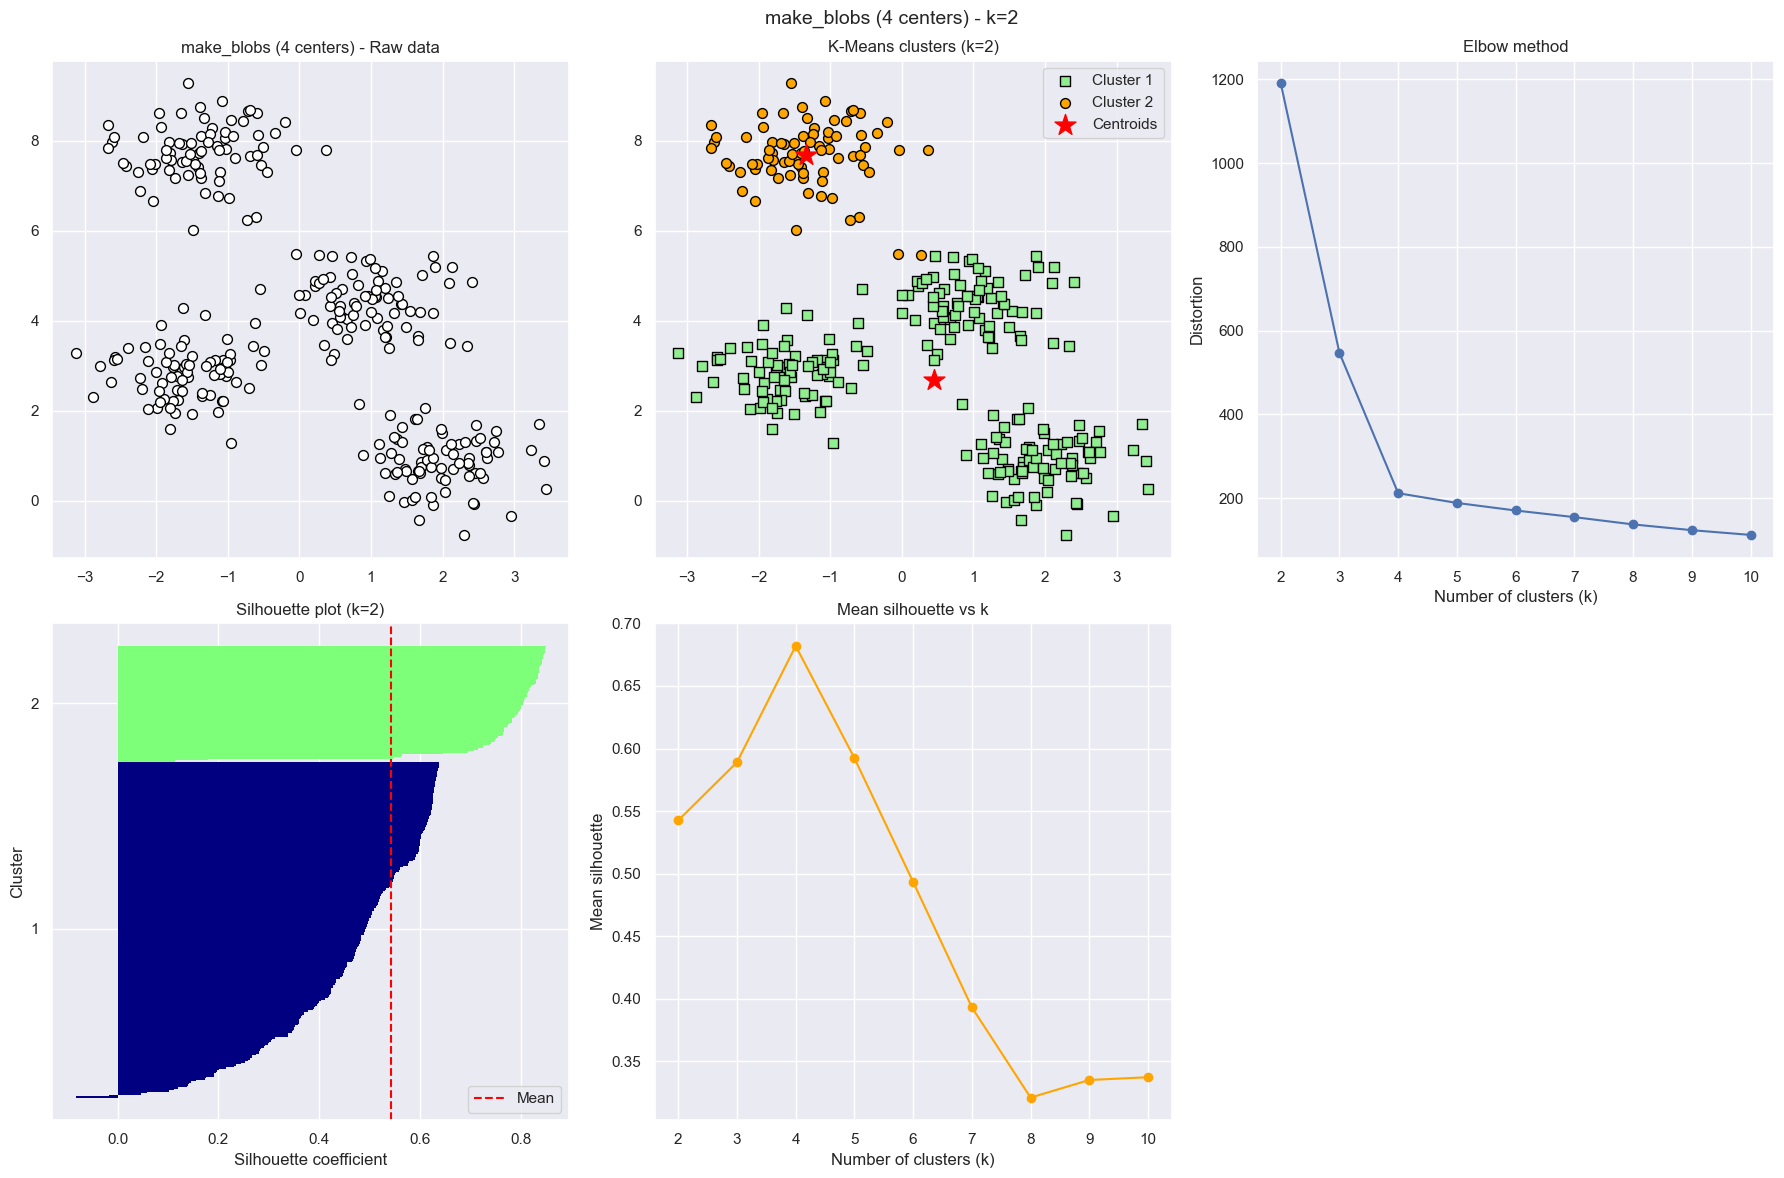


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95, 4.42) | (-0.89, 8.18)
 6      170.73     0.49344                                          

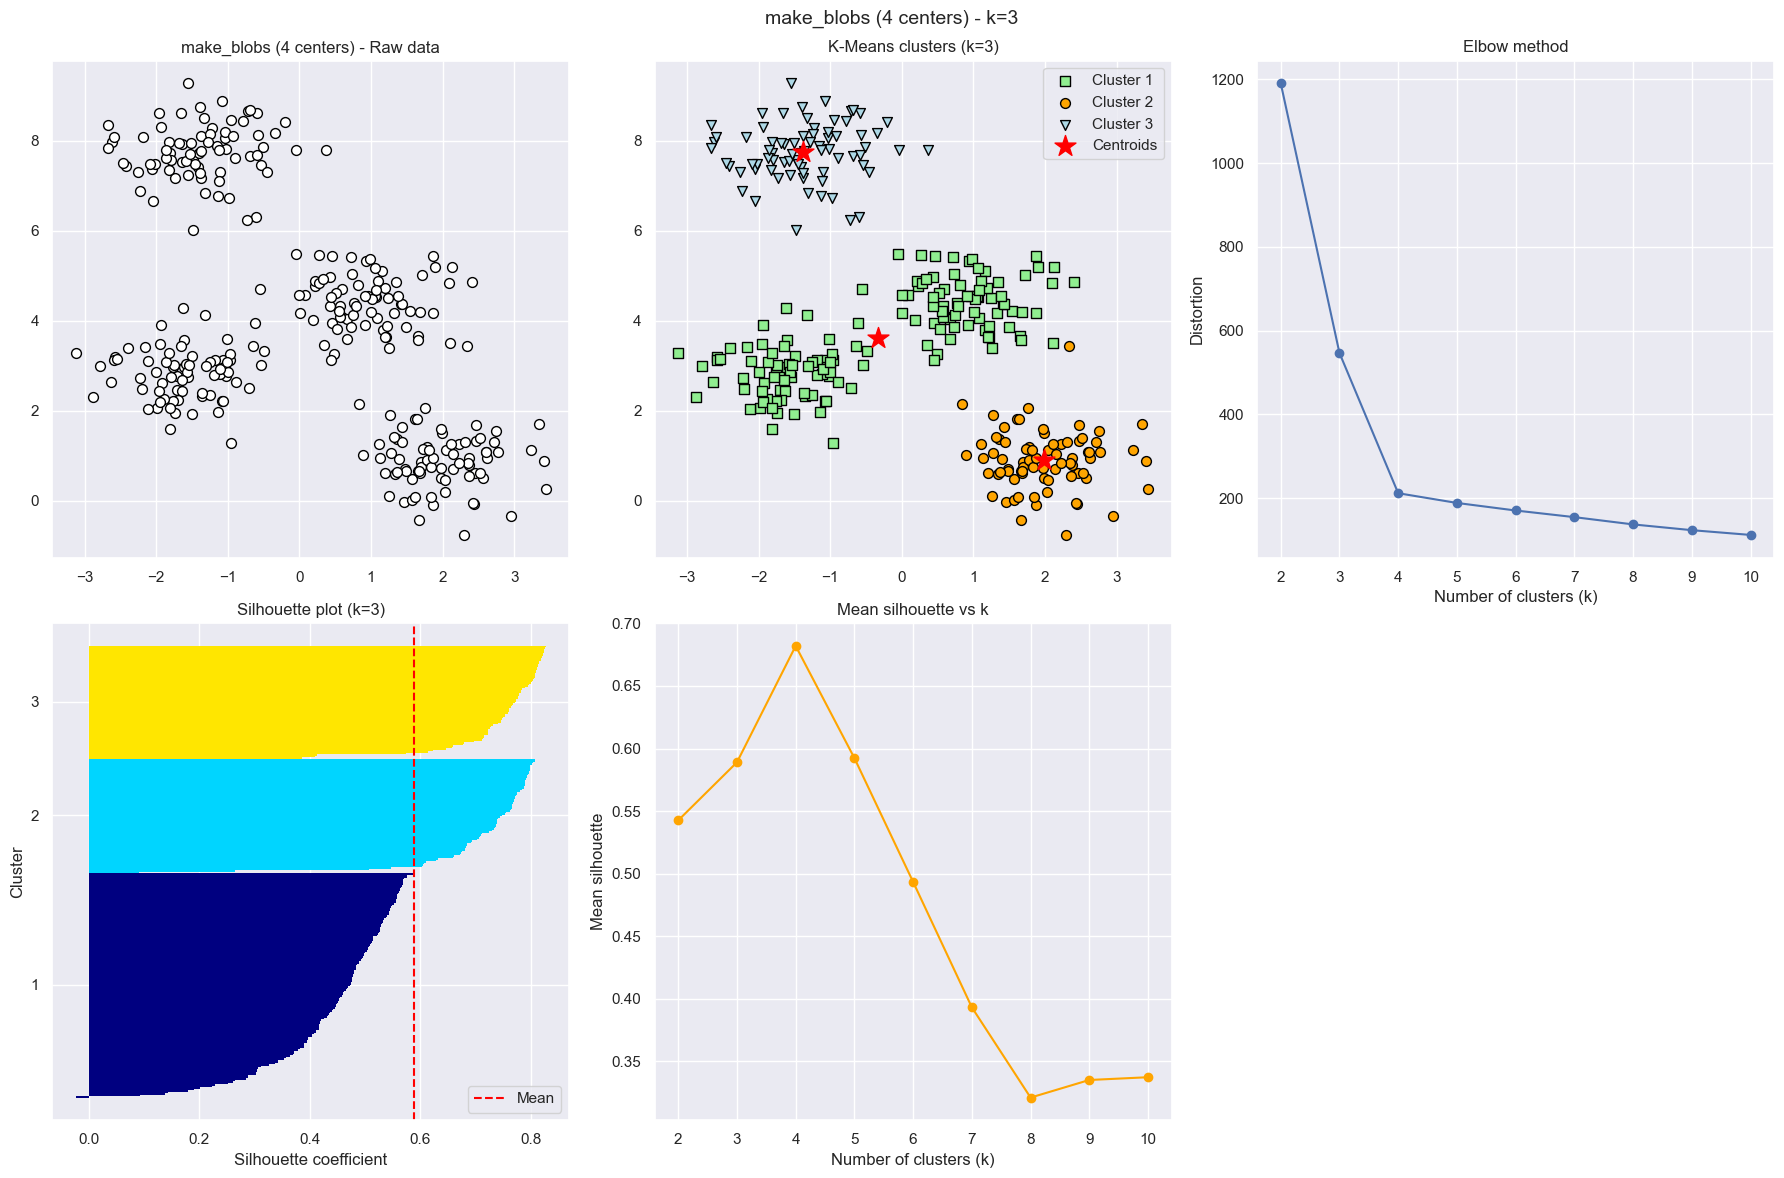


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

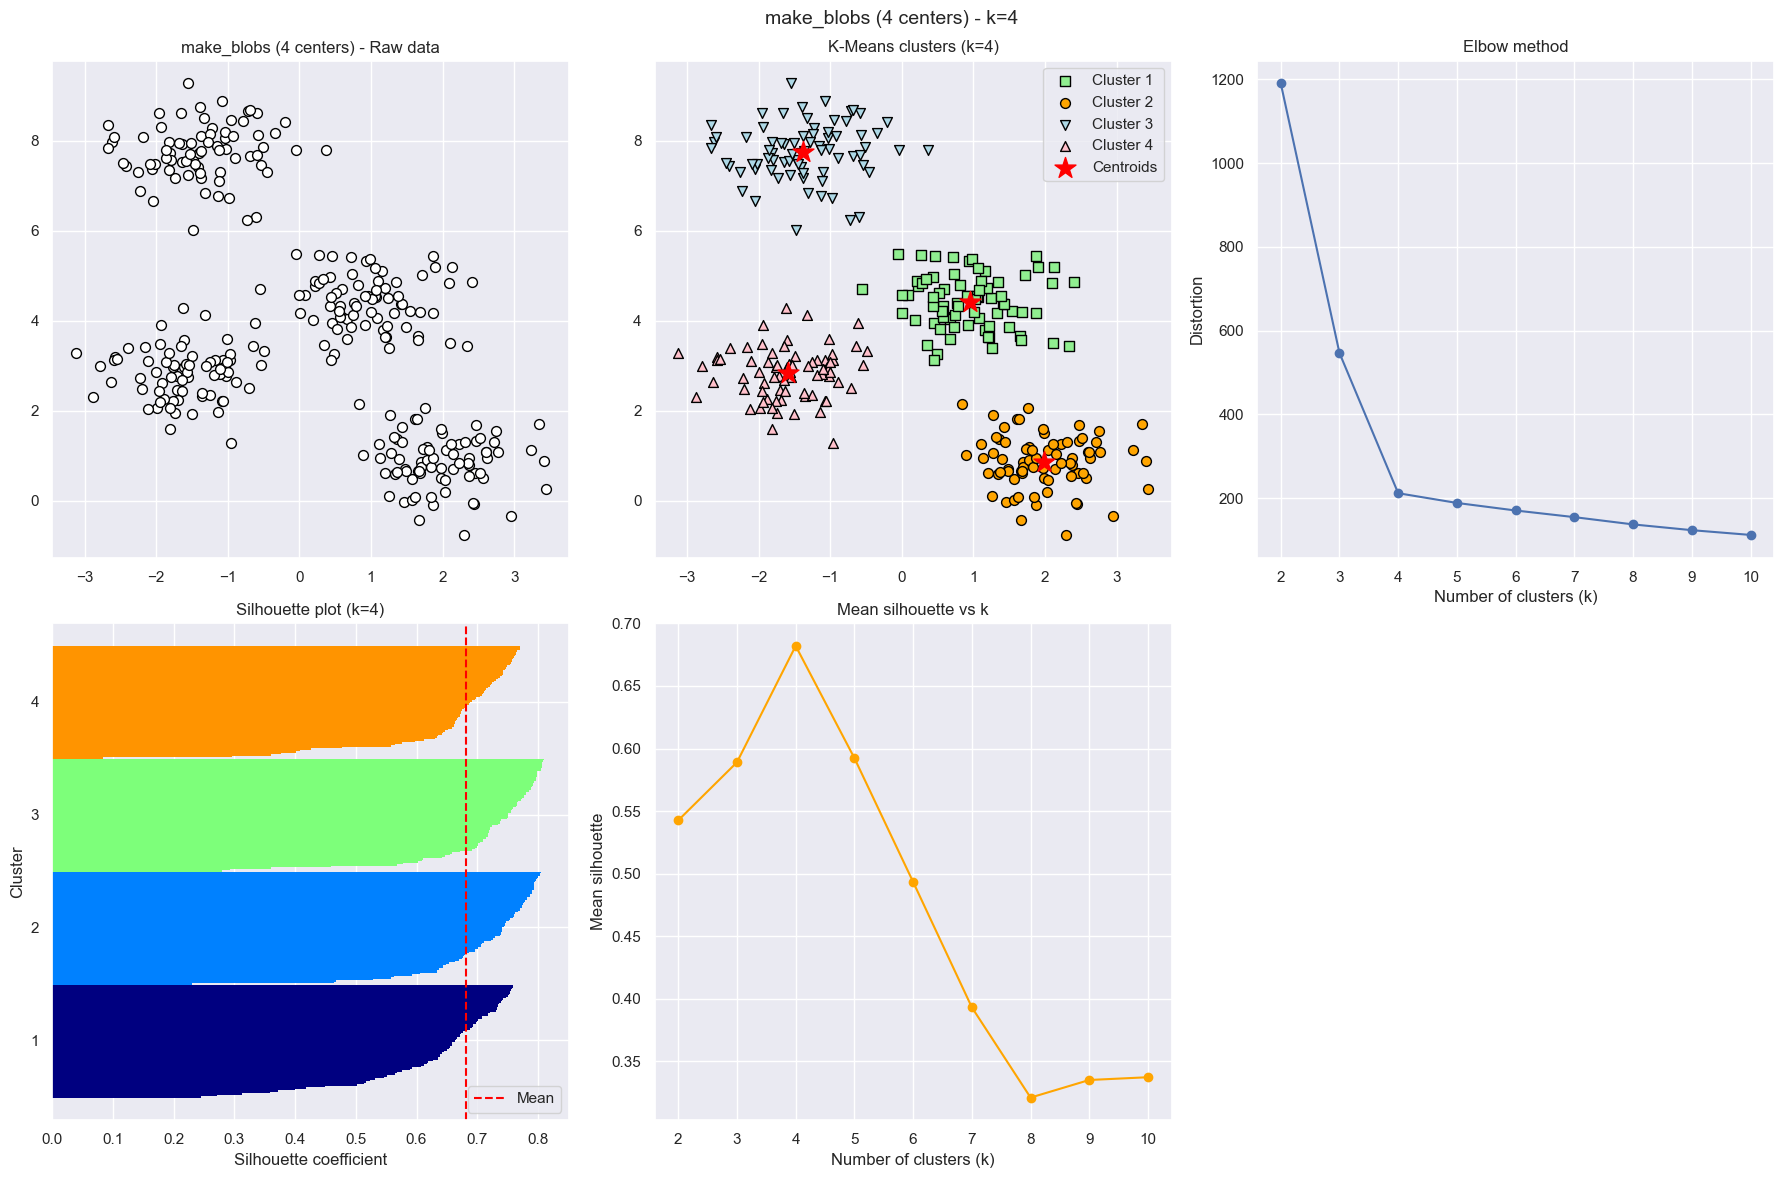


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

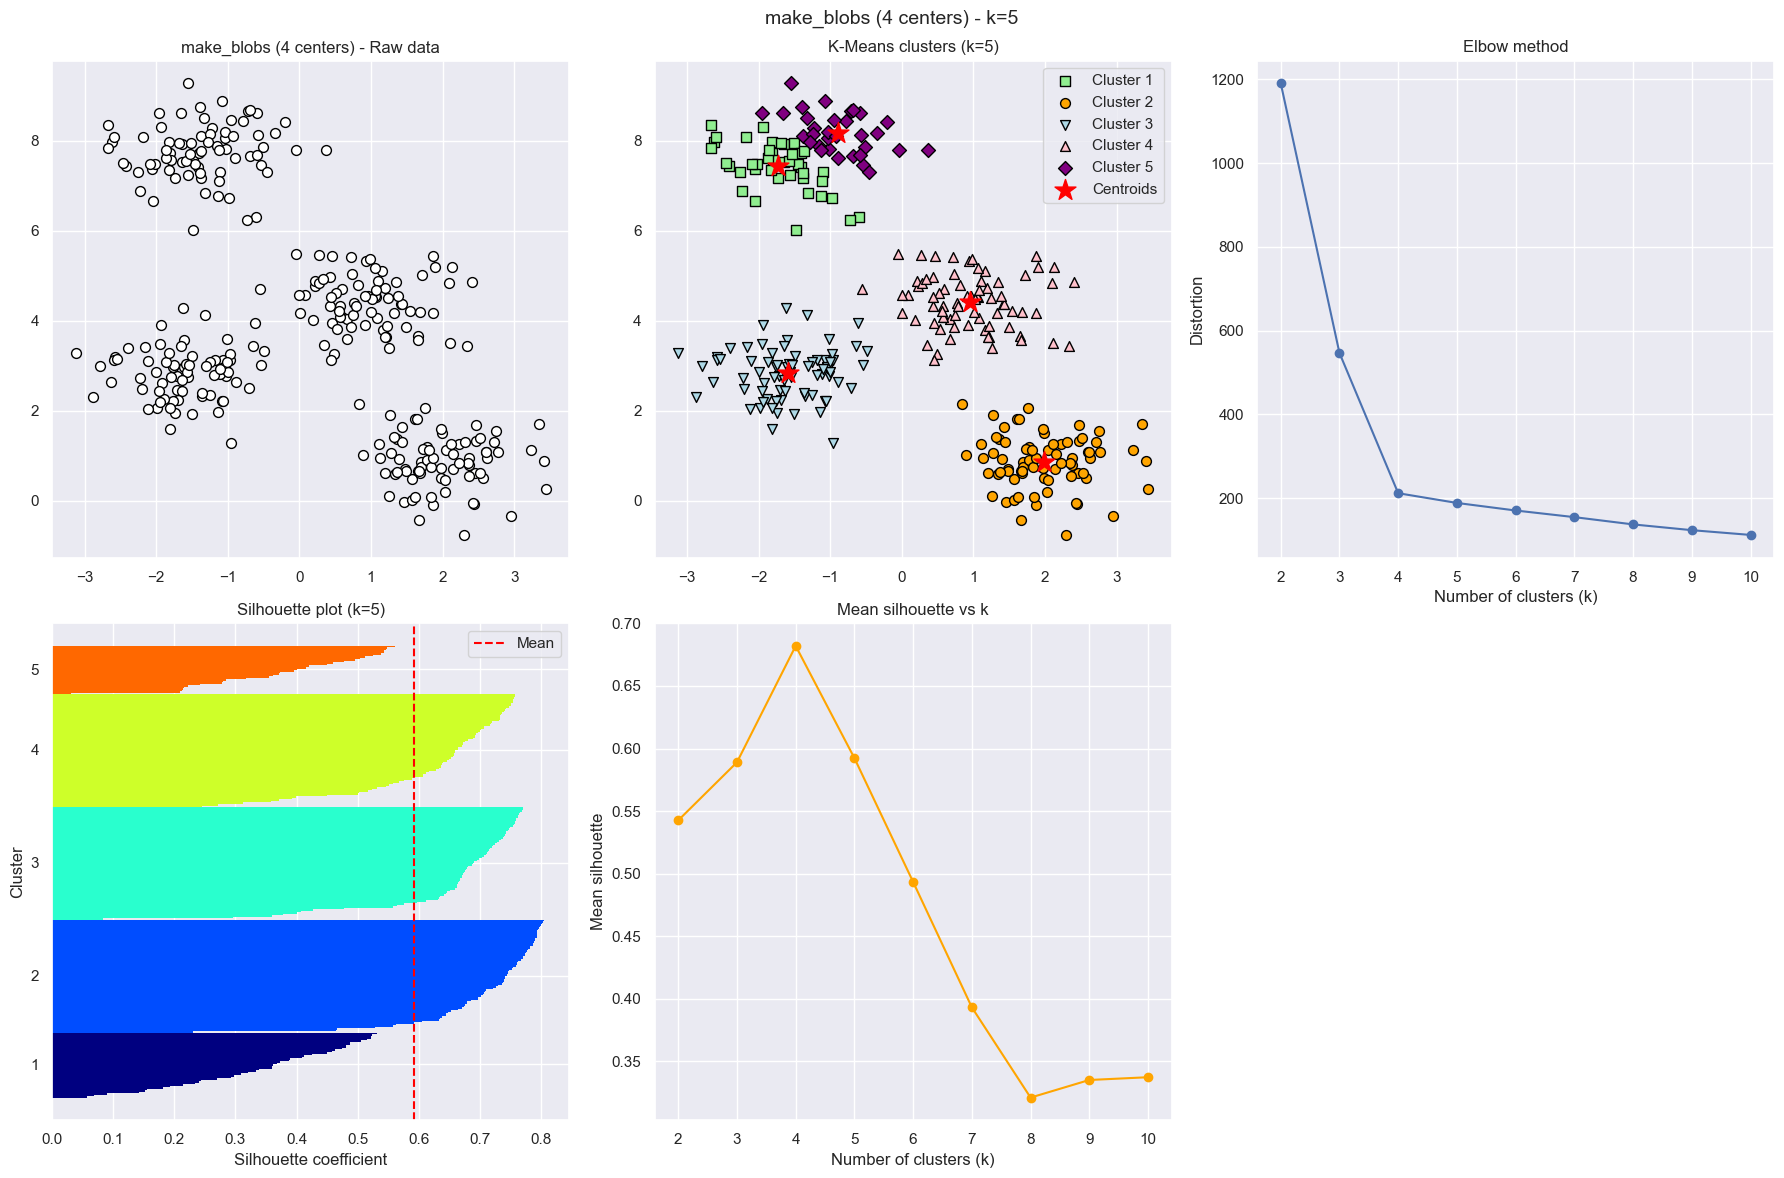


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

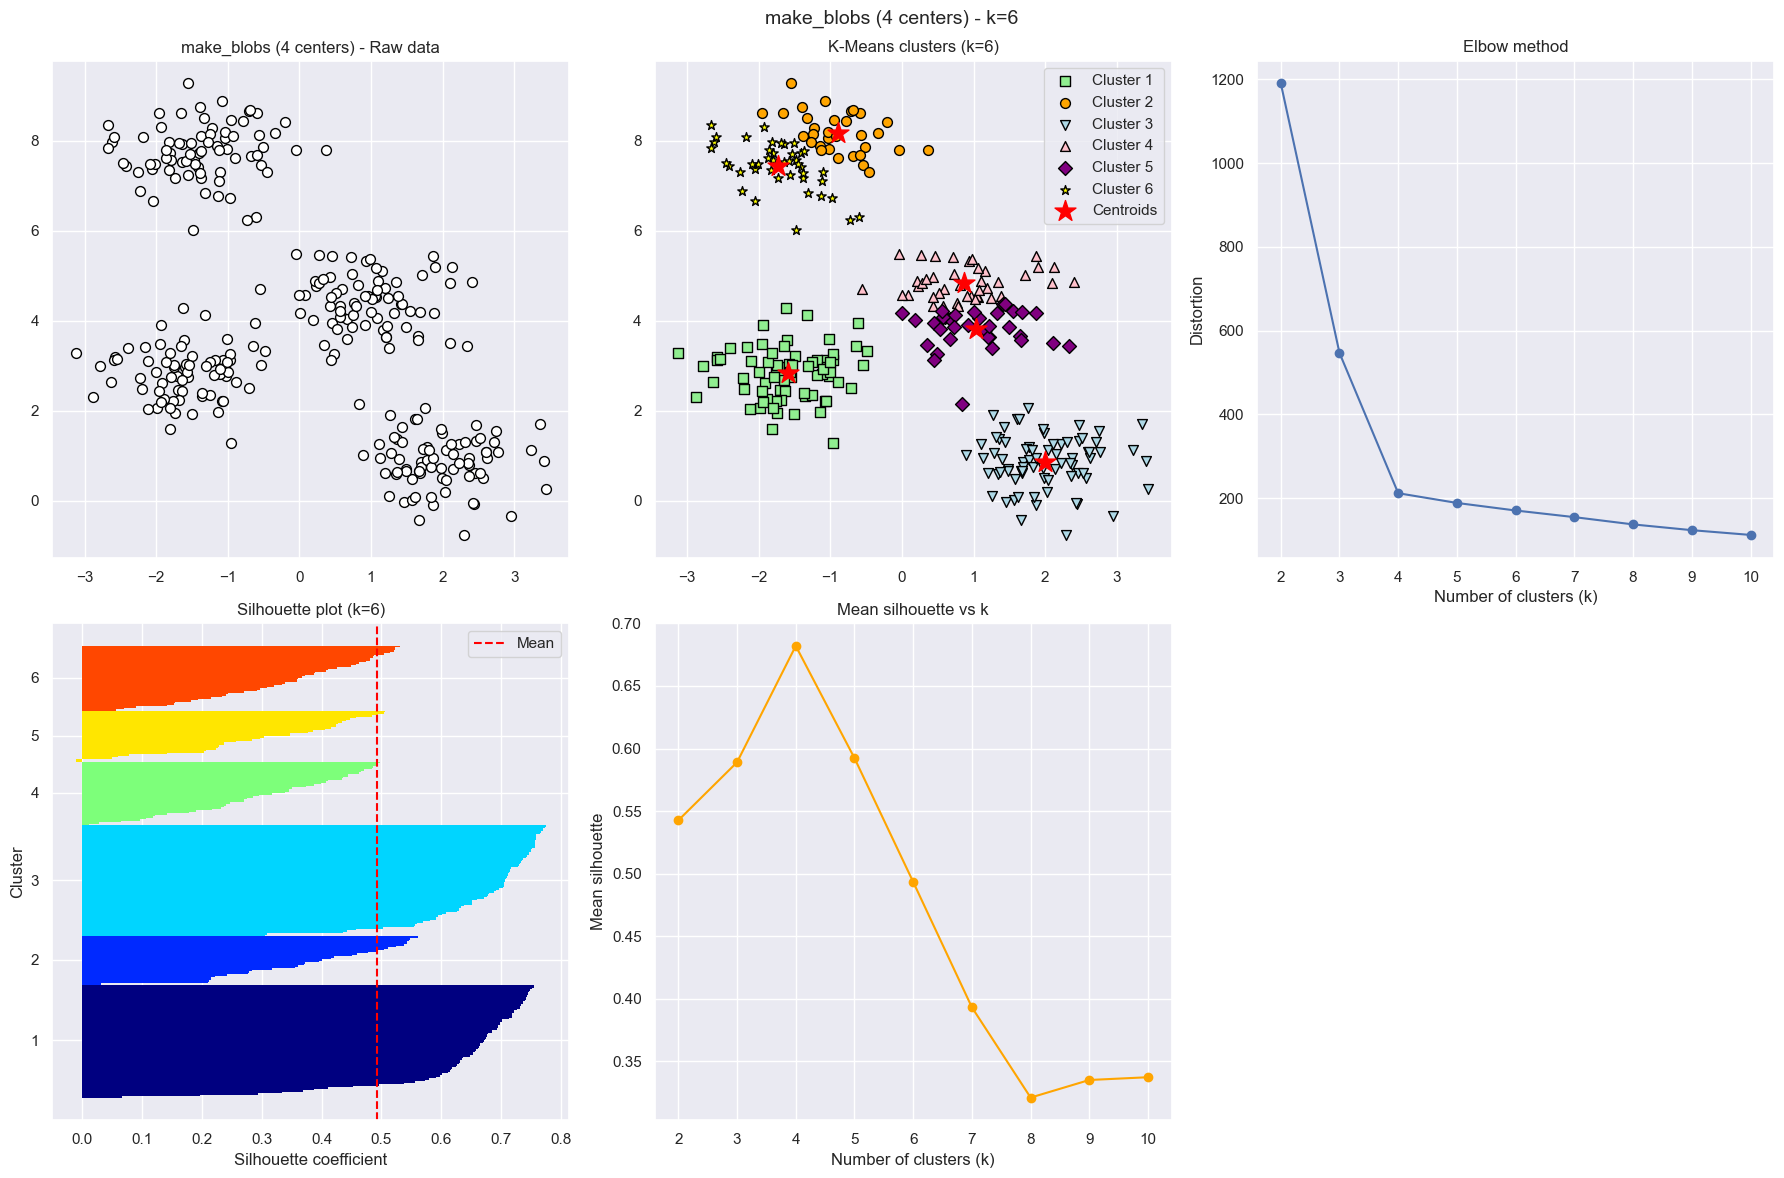


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

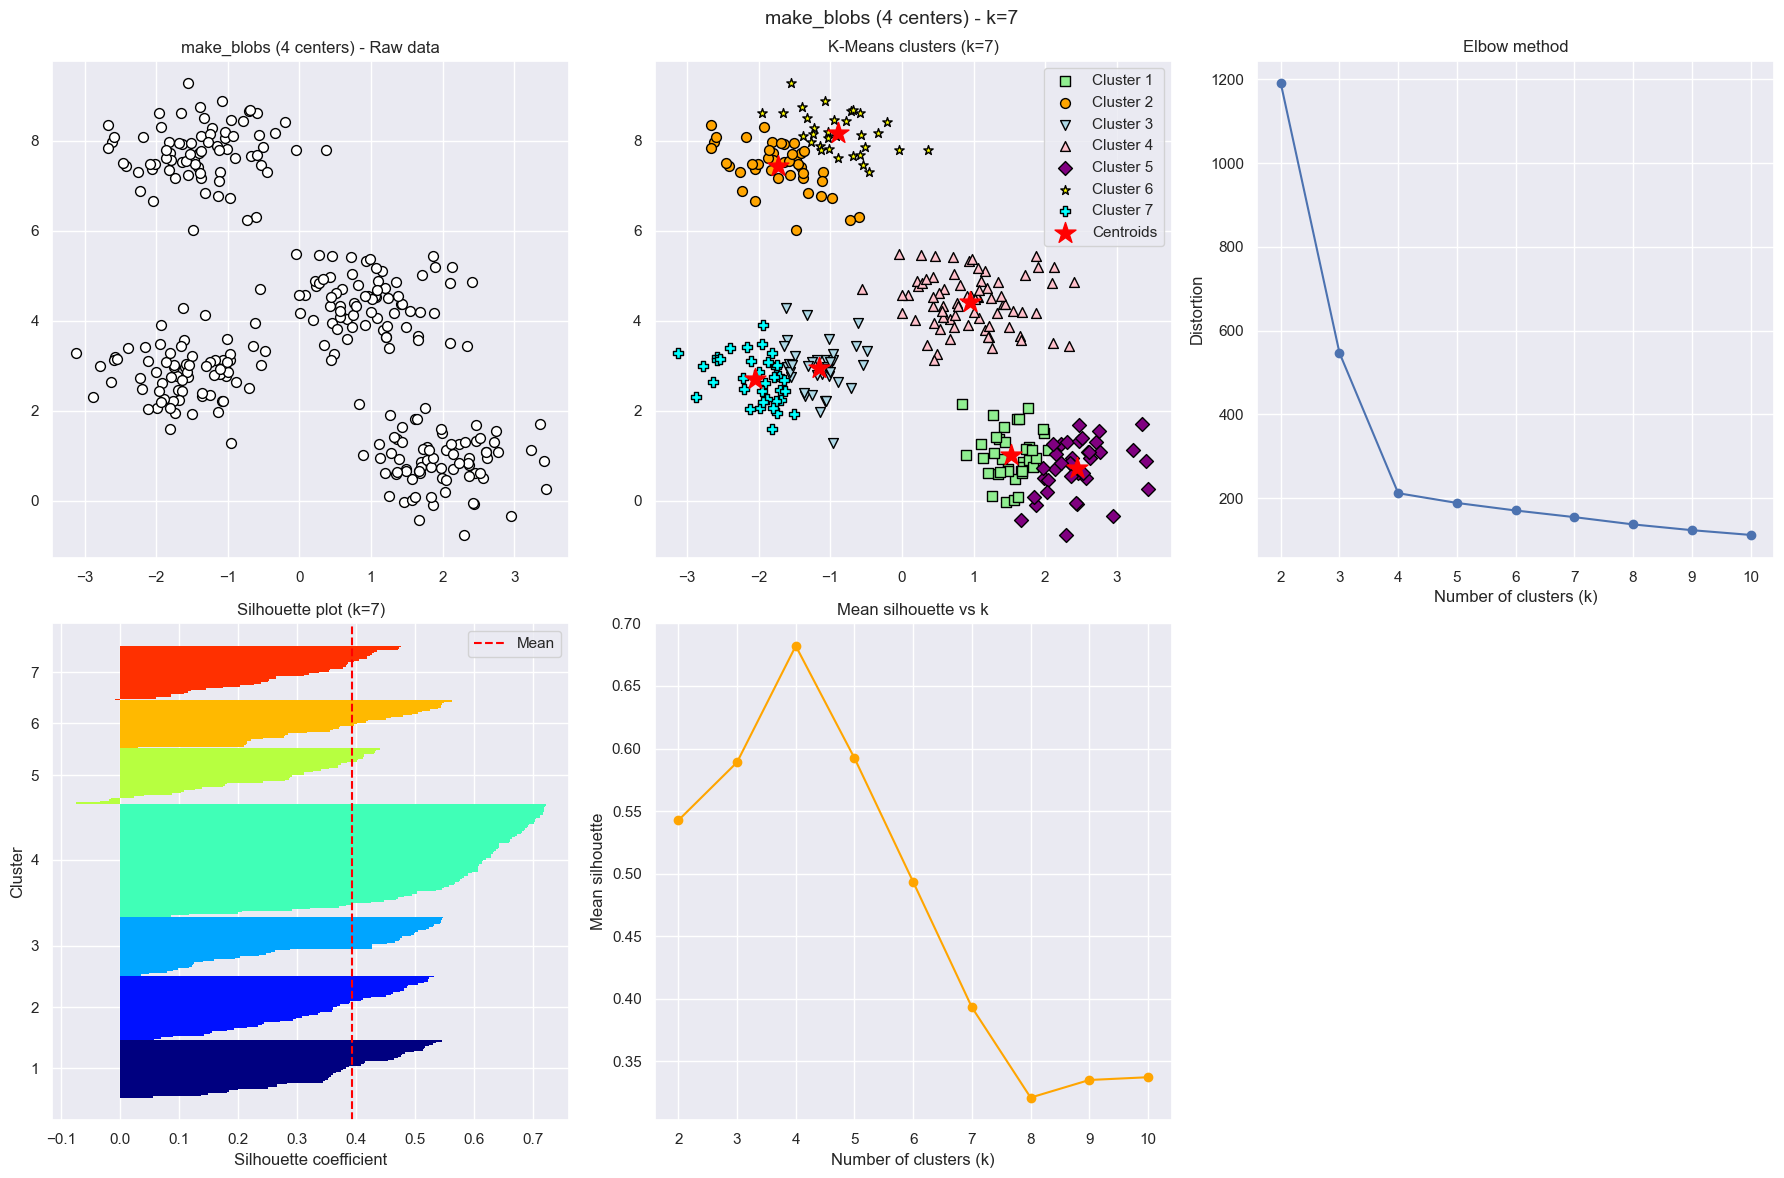


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

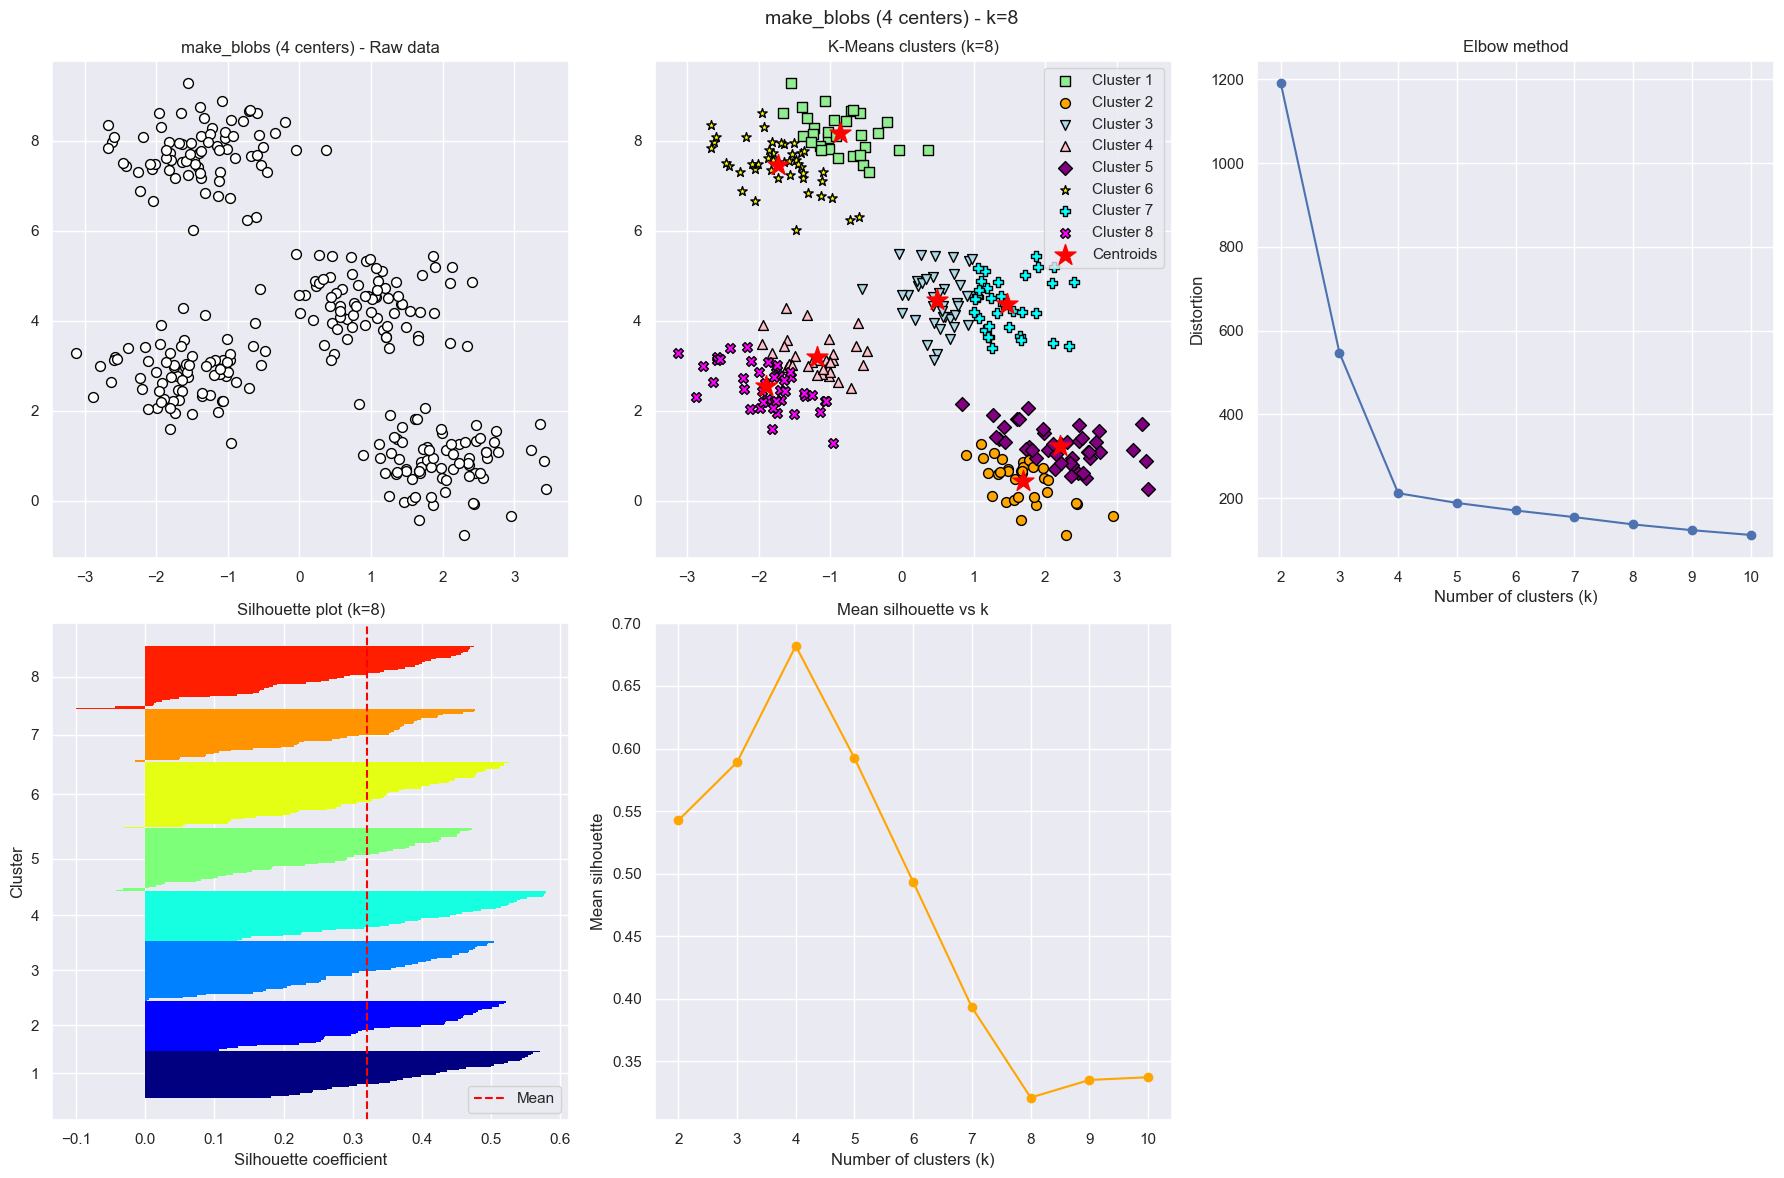


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

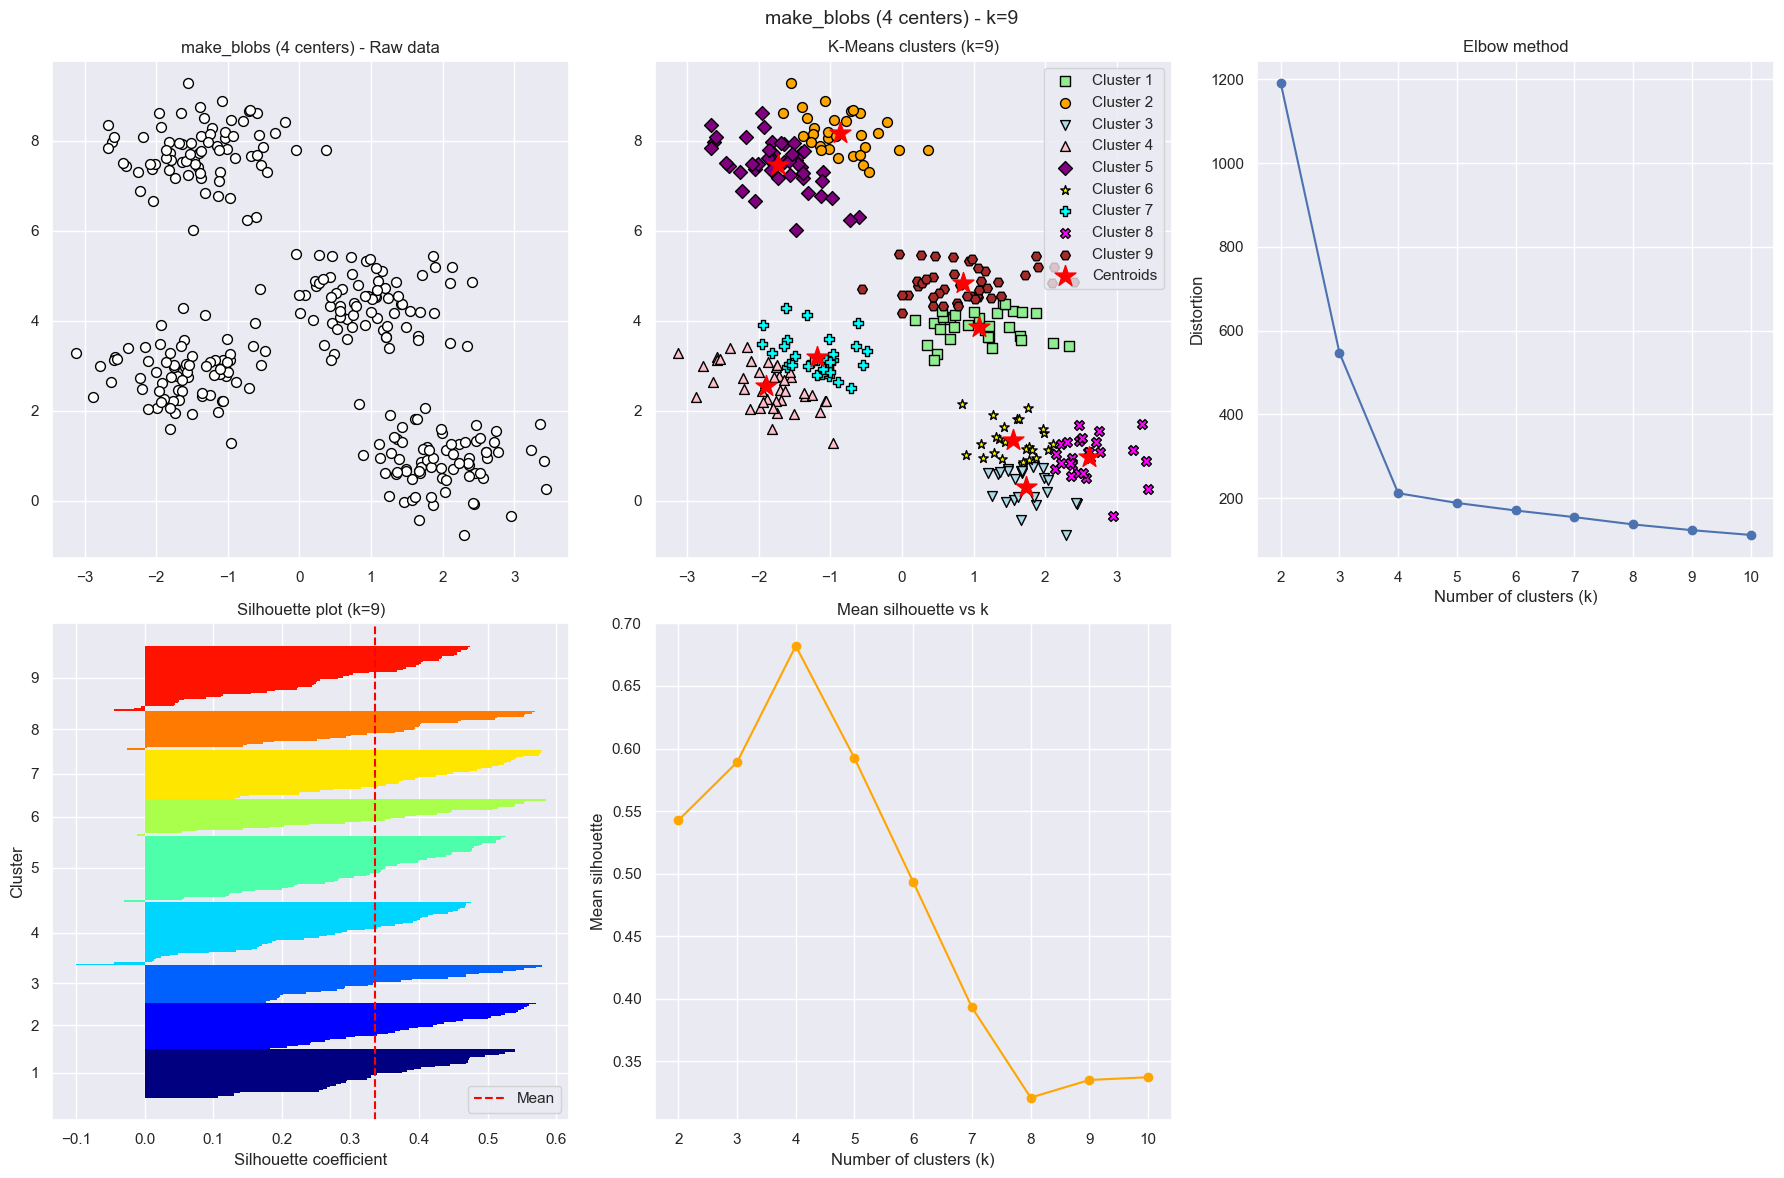


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

C:\Users\Manuel\AppData\Local\Temp\ipykernel_17828\2645685922.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[1].scatter(


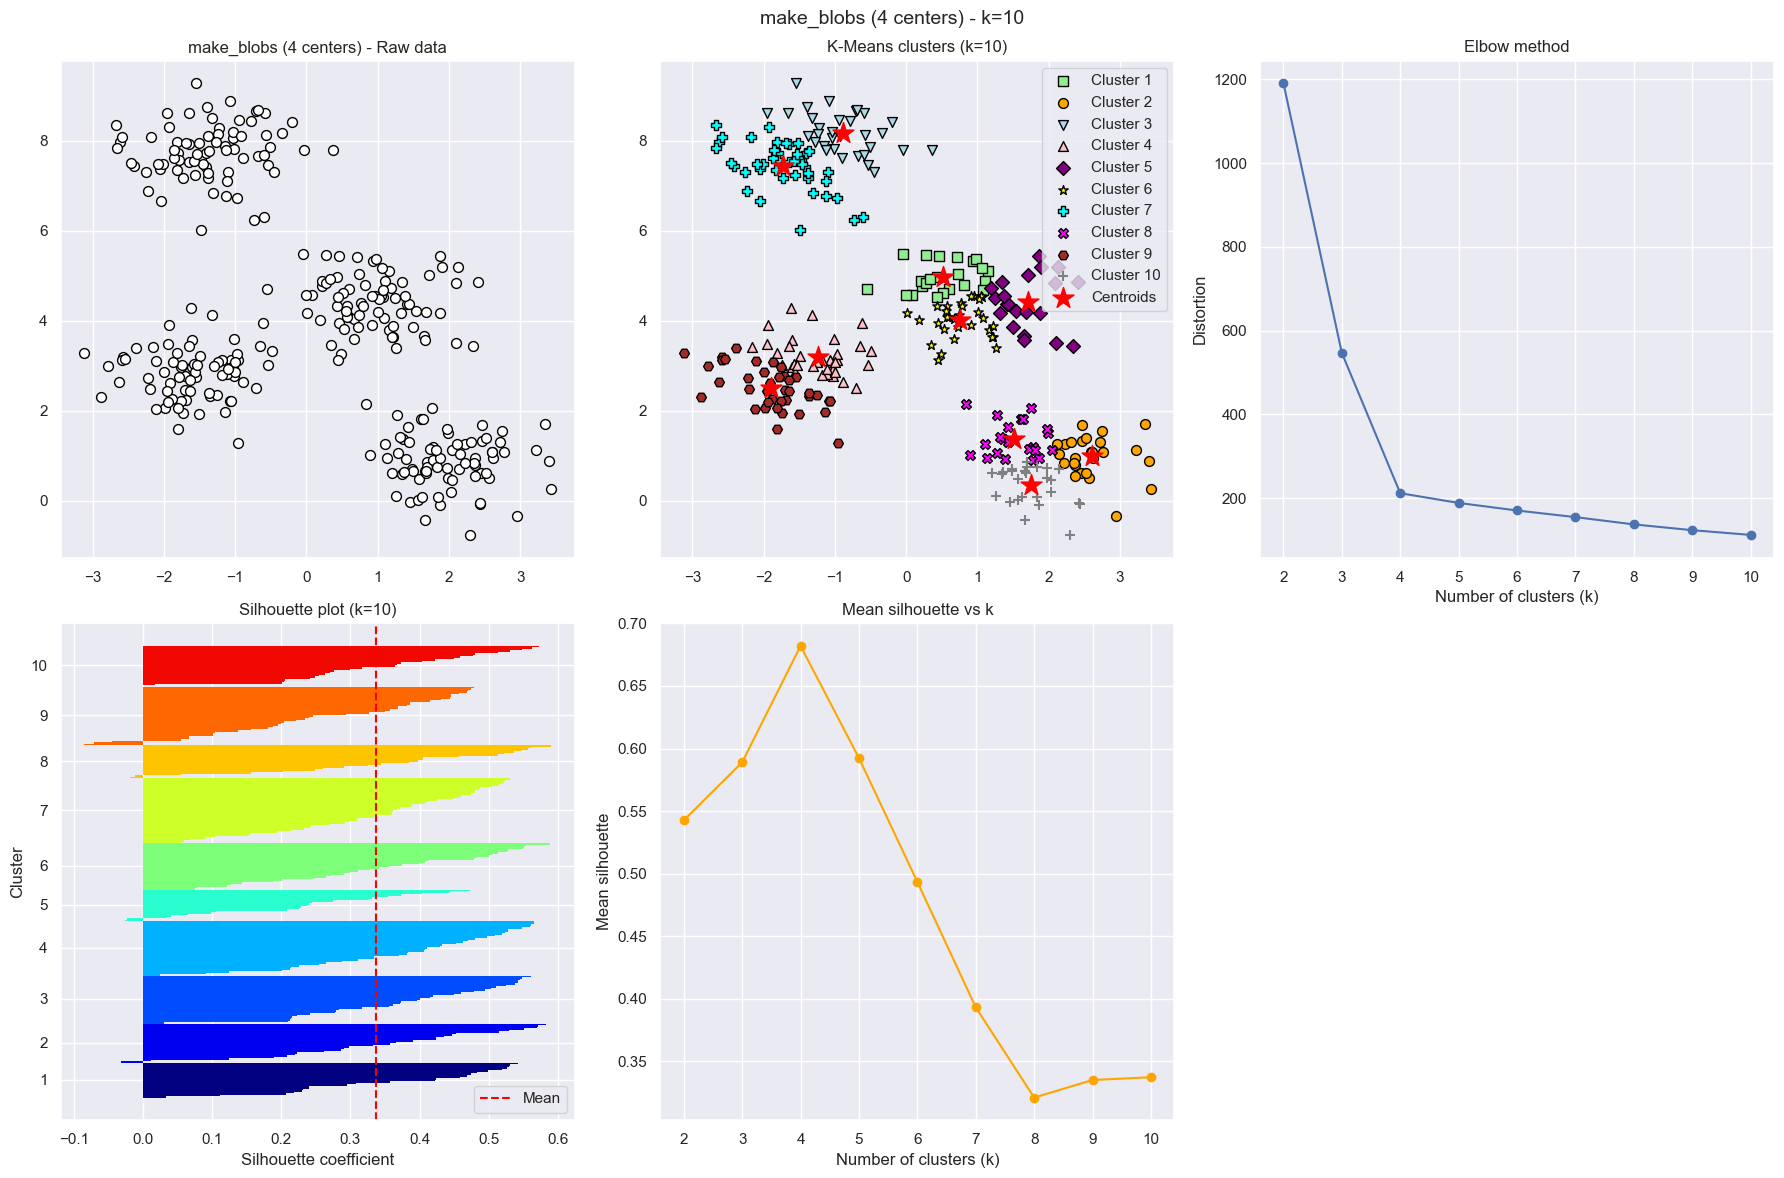


Results for make_blobs (4 centers):
 k  distortion  silhouette                                                                                                                                               centroids                dataset
 2     1190.78     0.54264                                                                                                                            (0.45, 2.68) | (-1.33, 7.69) make_blobs (4 centers)
 3      546.89     0.58904                                                                                                            (-0.34, 3.63) | (1.99, 0.90) | (-1.37, 7.75) make_blobs (4 centers)
 4      212.01     0.68199                                                                                             (0.95, 4.42) | (1.98, 0.87) | (-1.37, 7.75) | (-1.58, 2.83) make_blobs (4 centers)
 5      188.77     0.59239                                                                             (-1.73, 7.43) | (1.98, 0.87) | (-1.58, 2.83) | (0.95

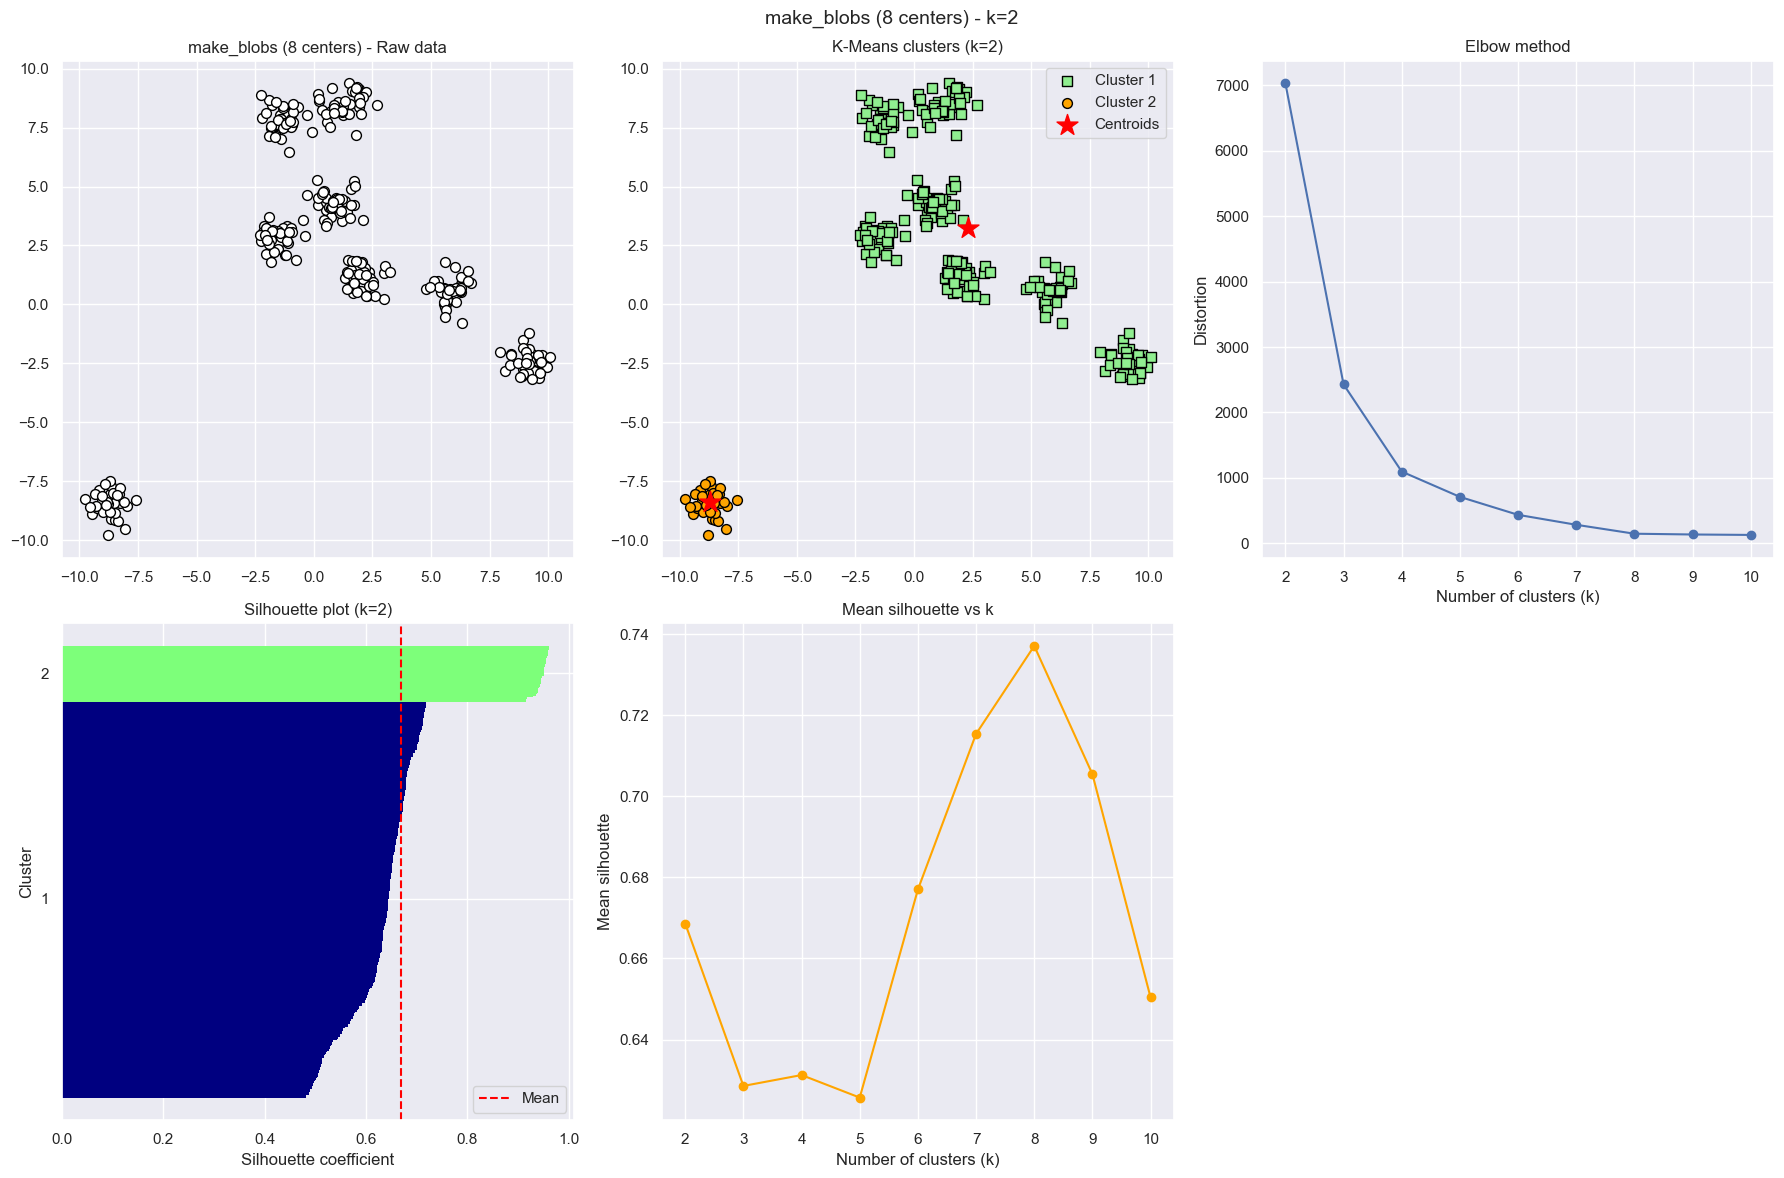


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (-0.05, 8.16) | (9.16, -2.45)
 6      433.67     0.67701                                     

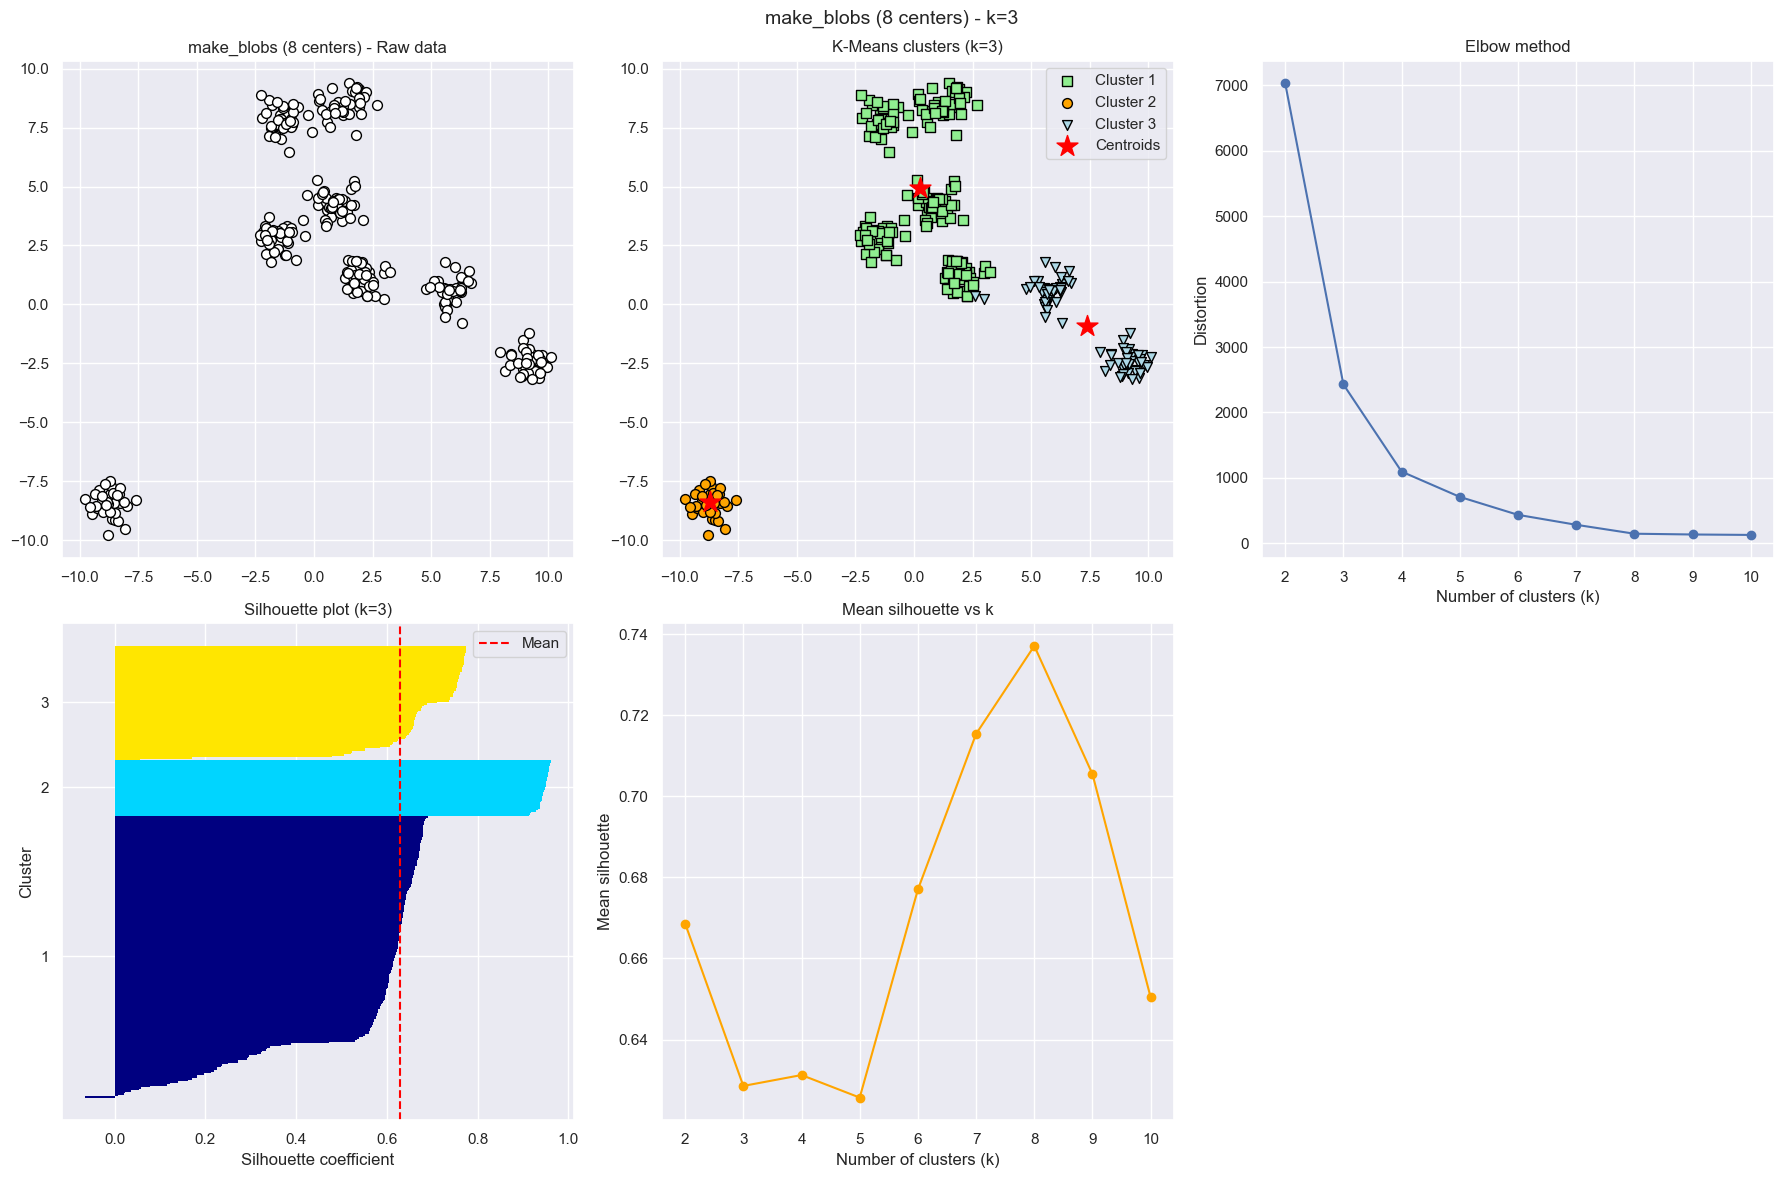


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

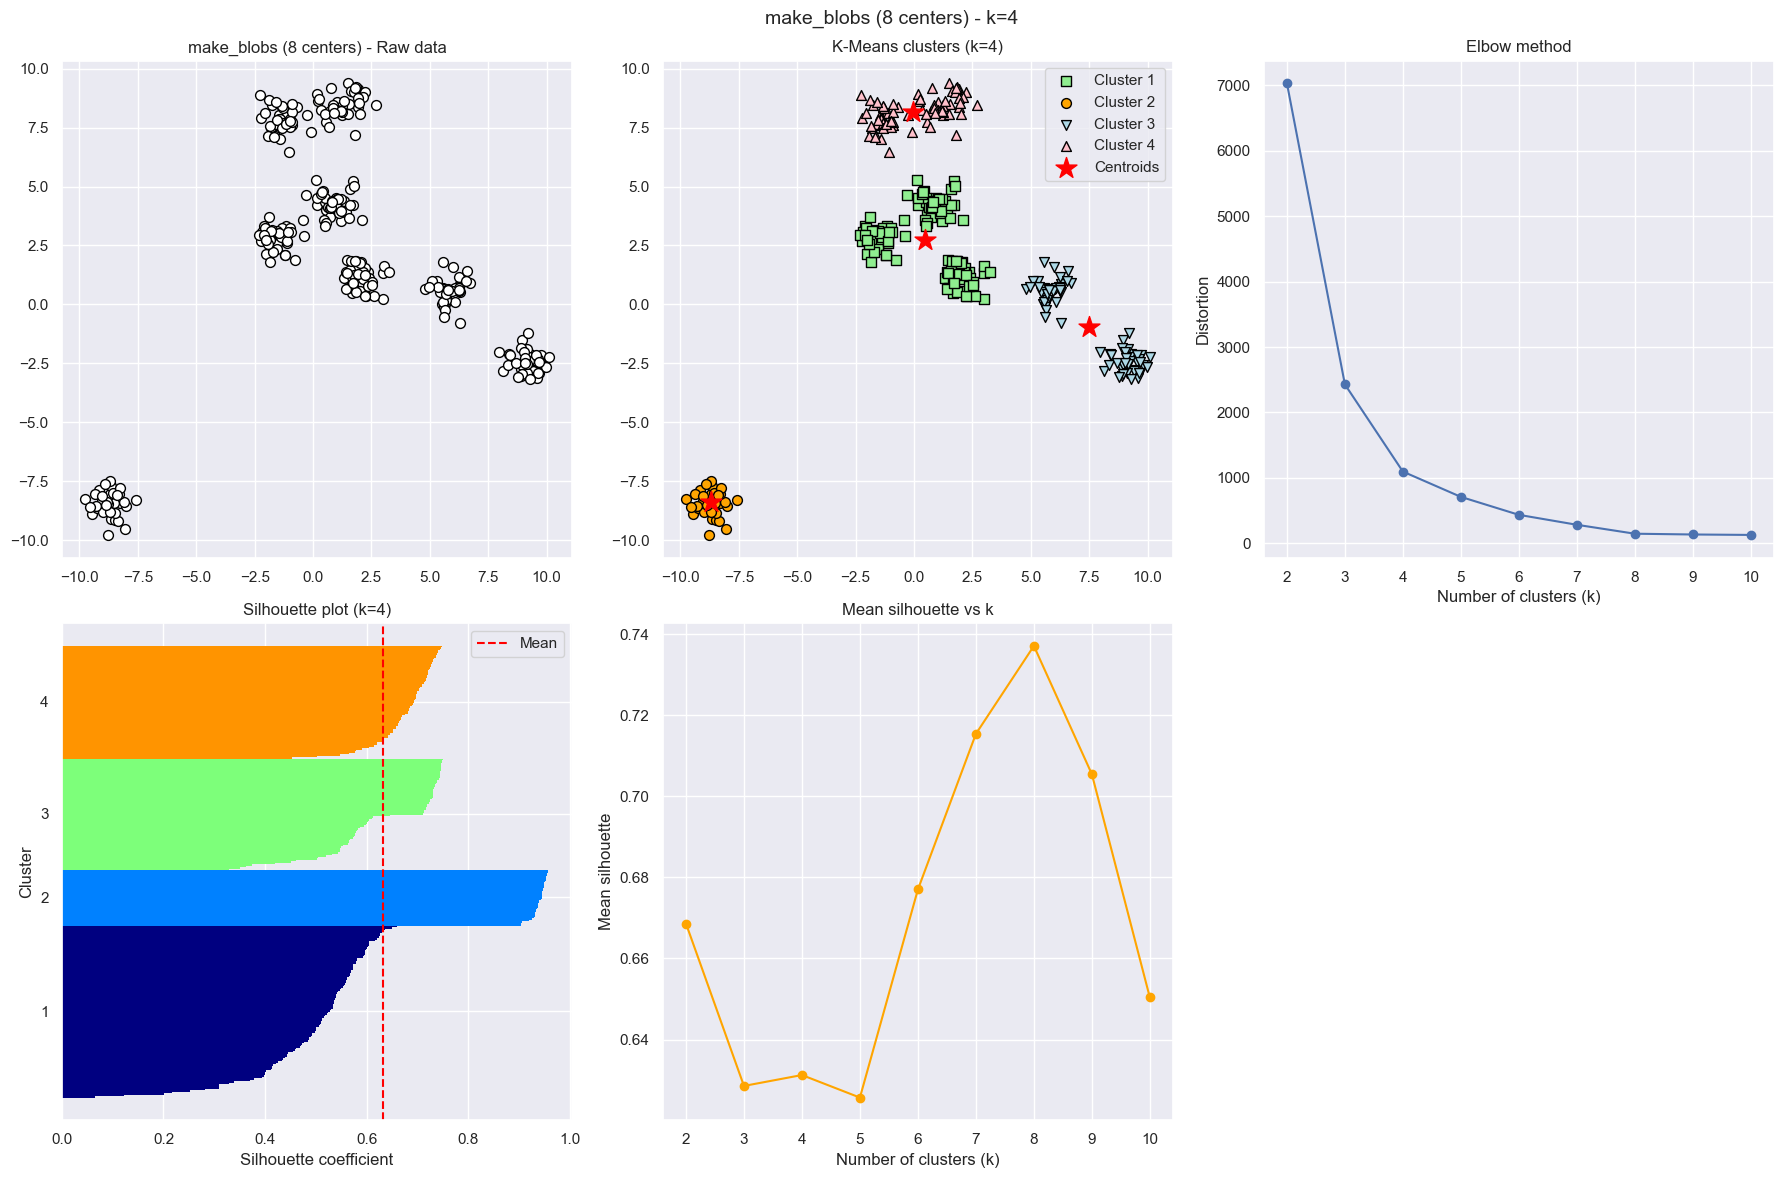


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

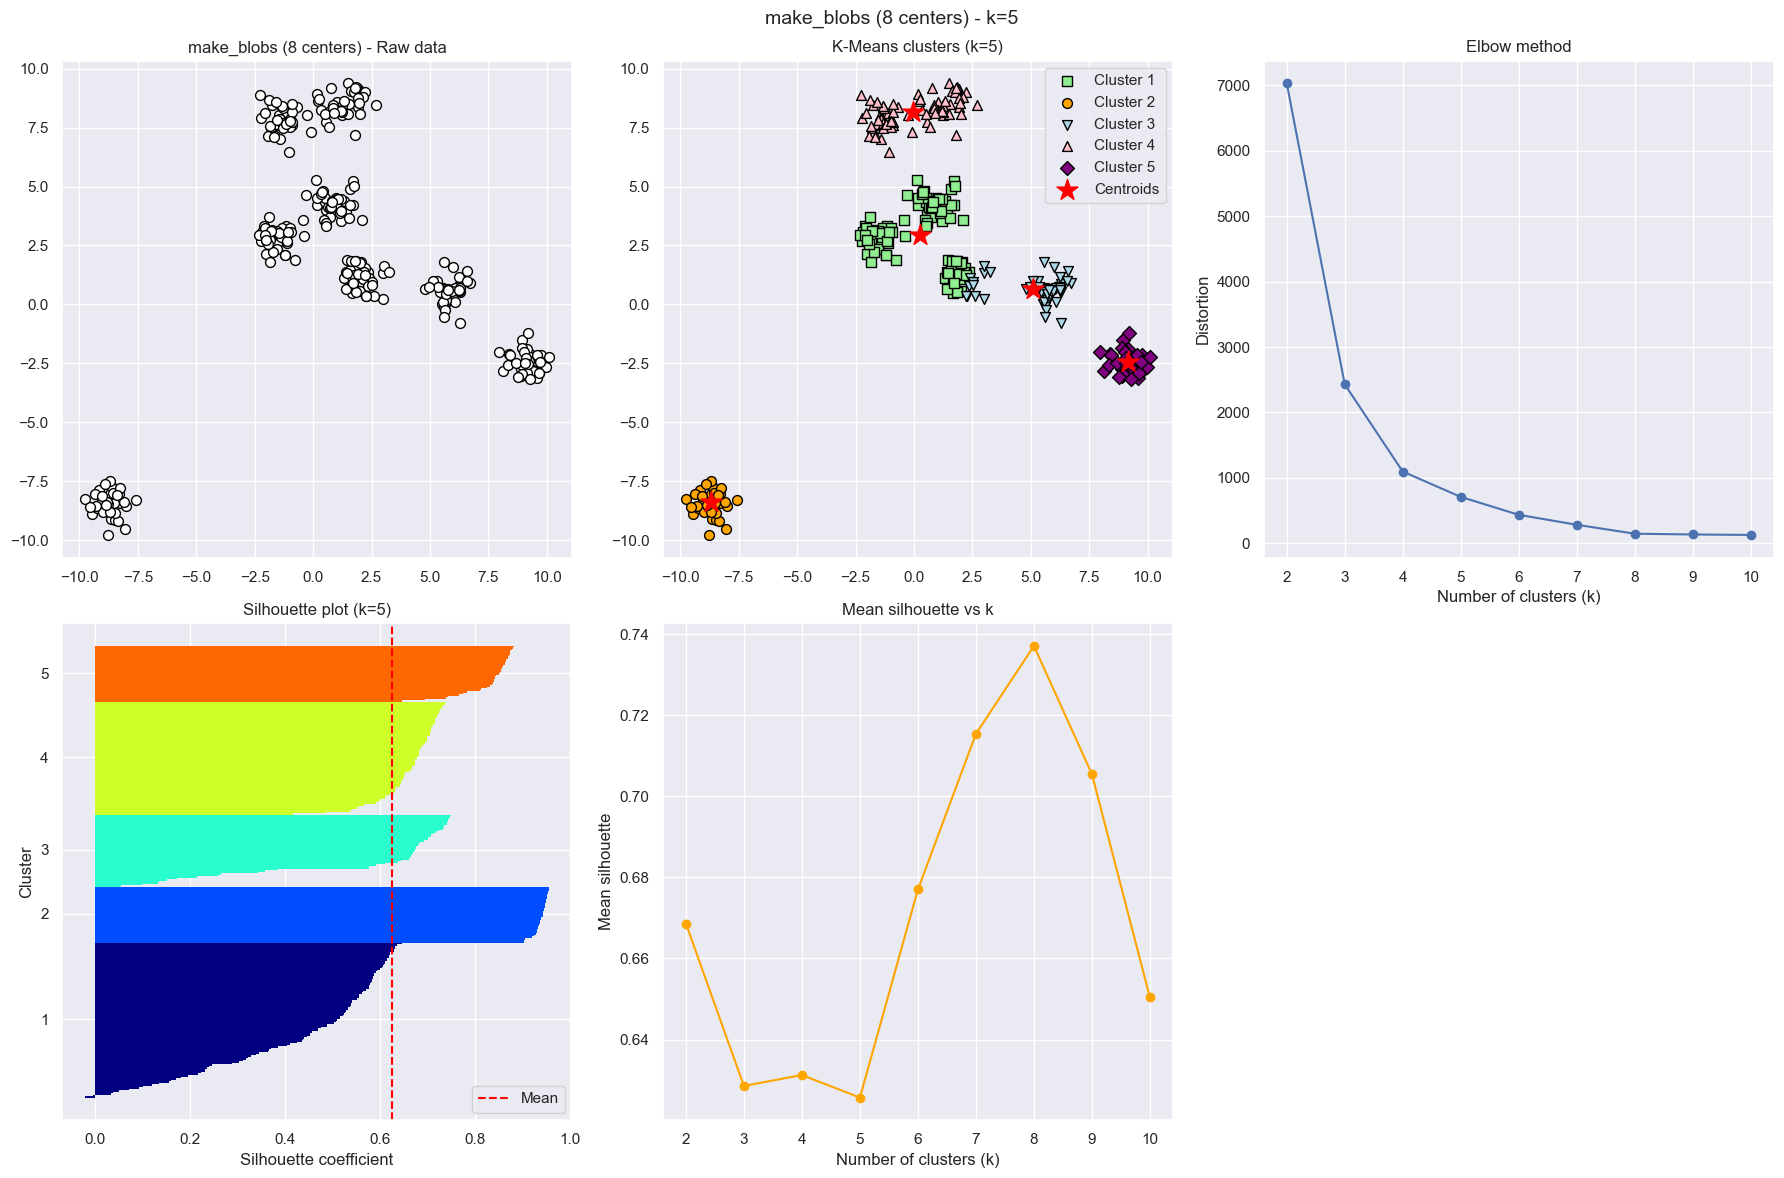


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

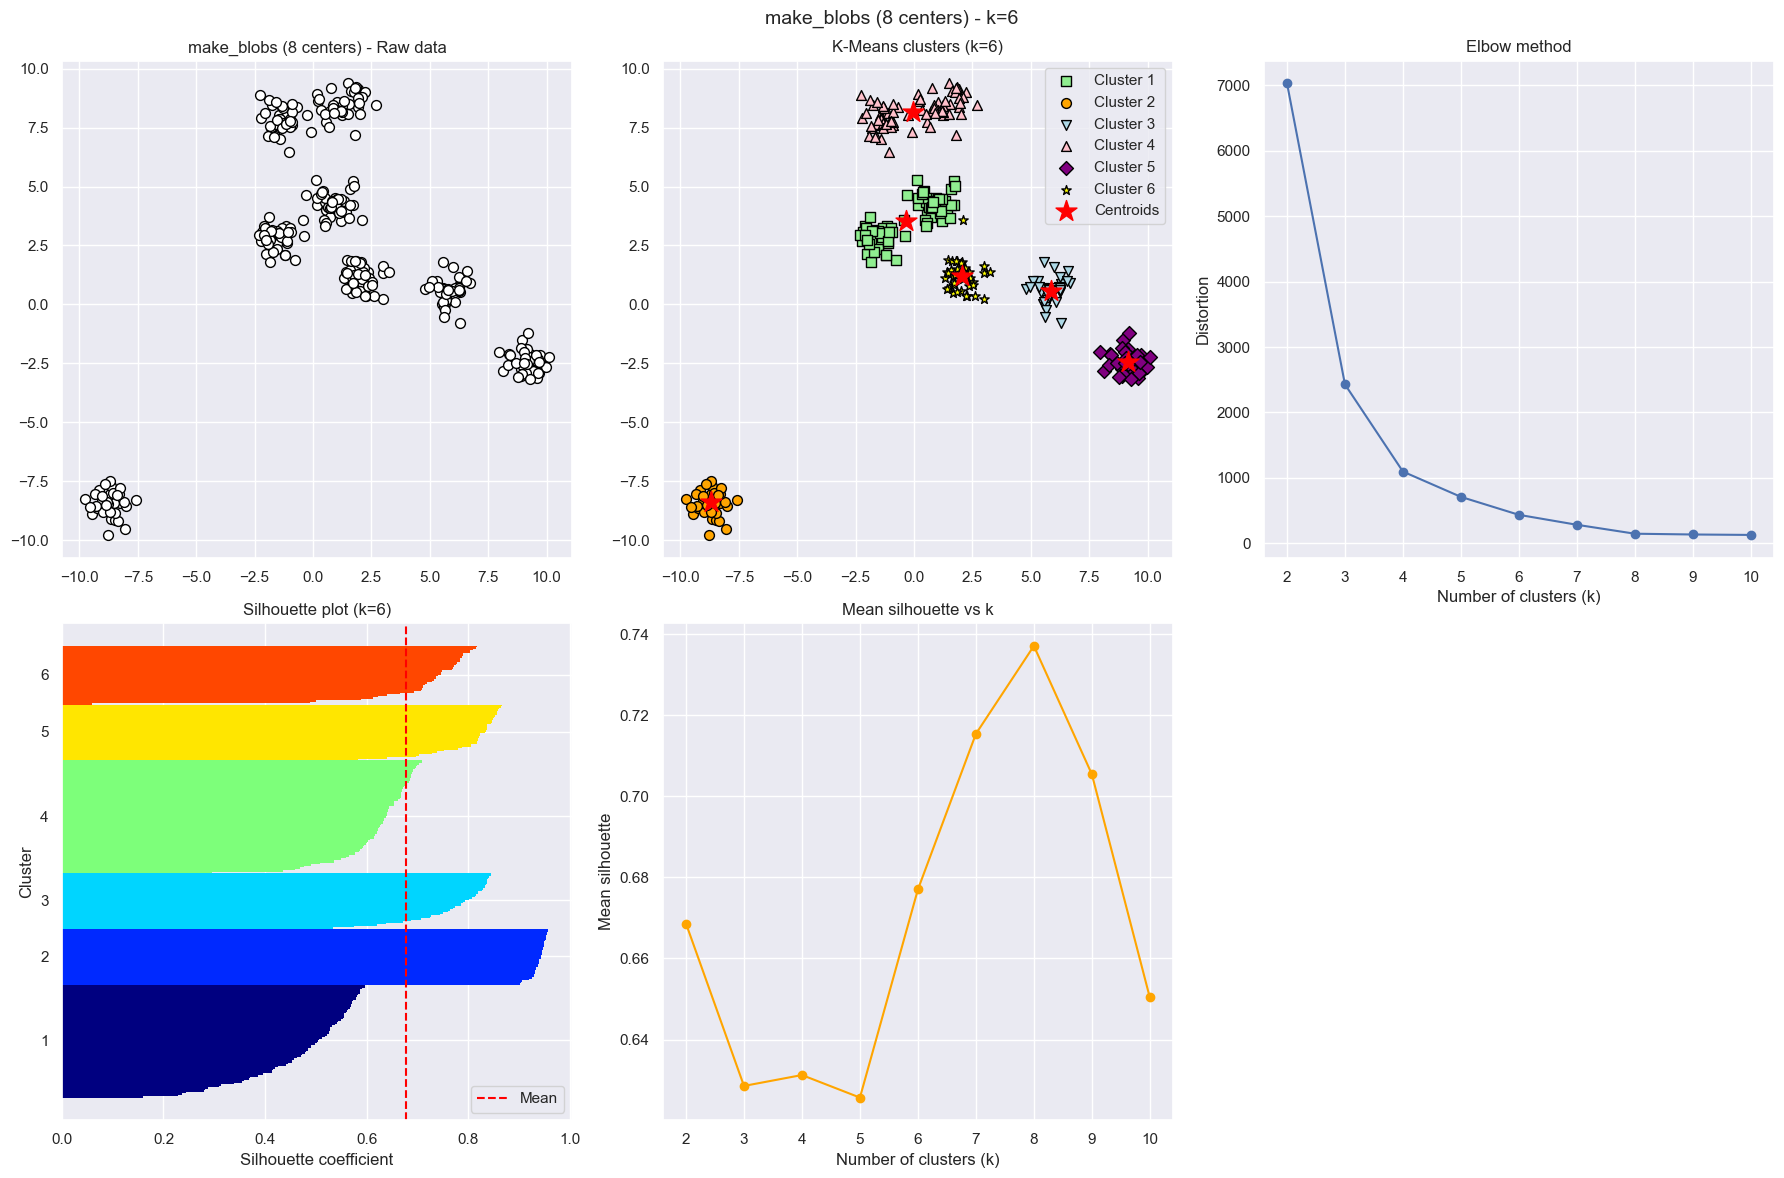


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

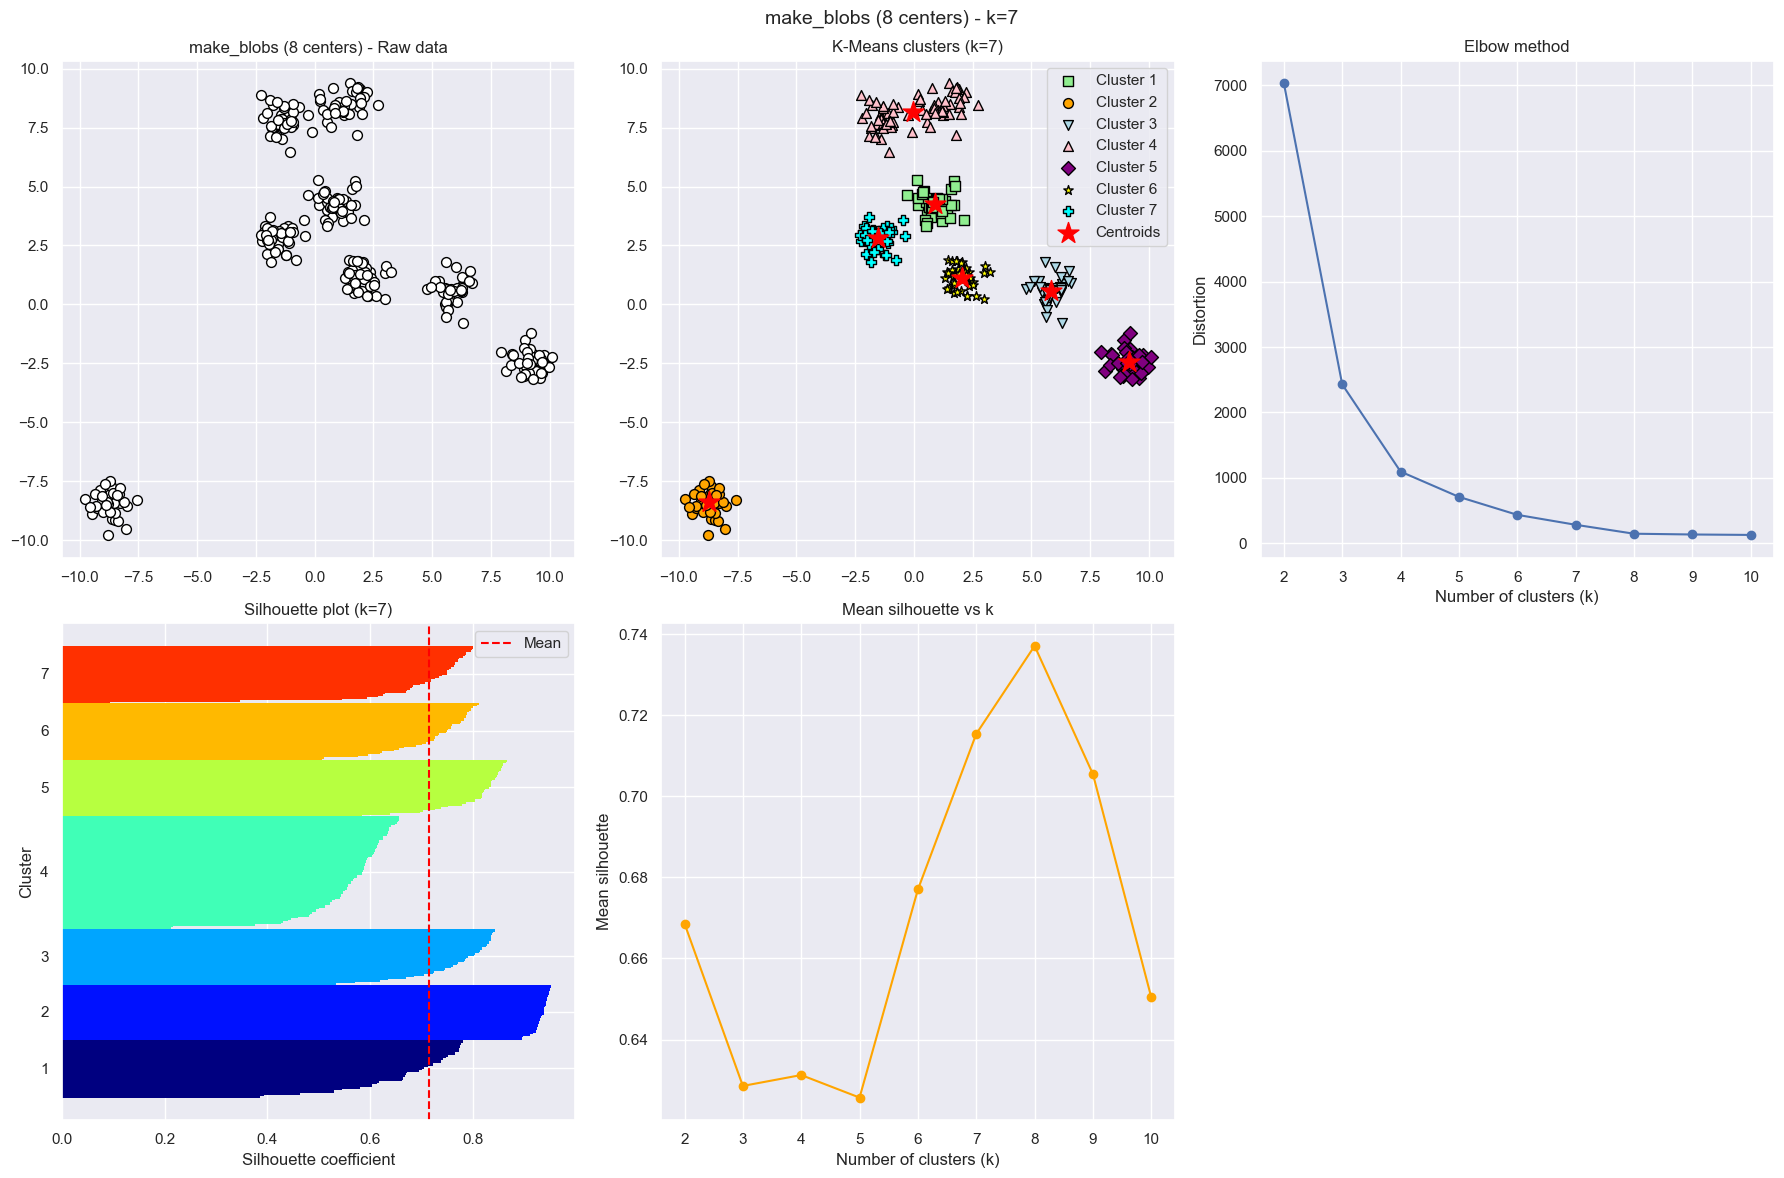


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

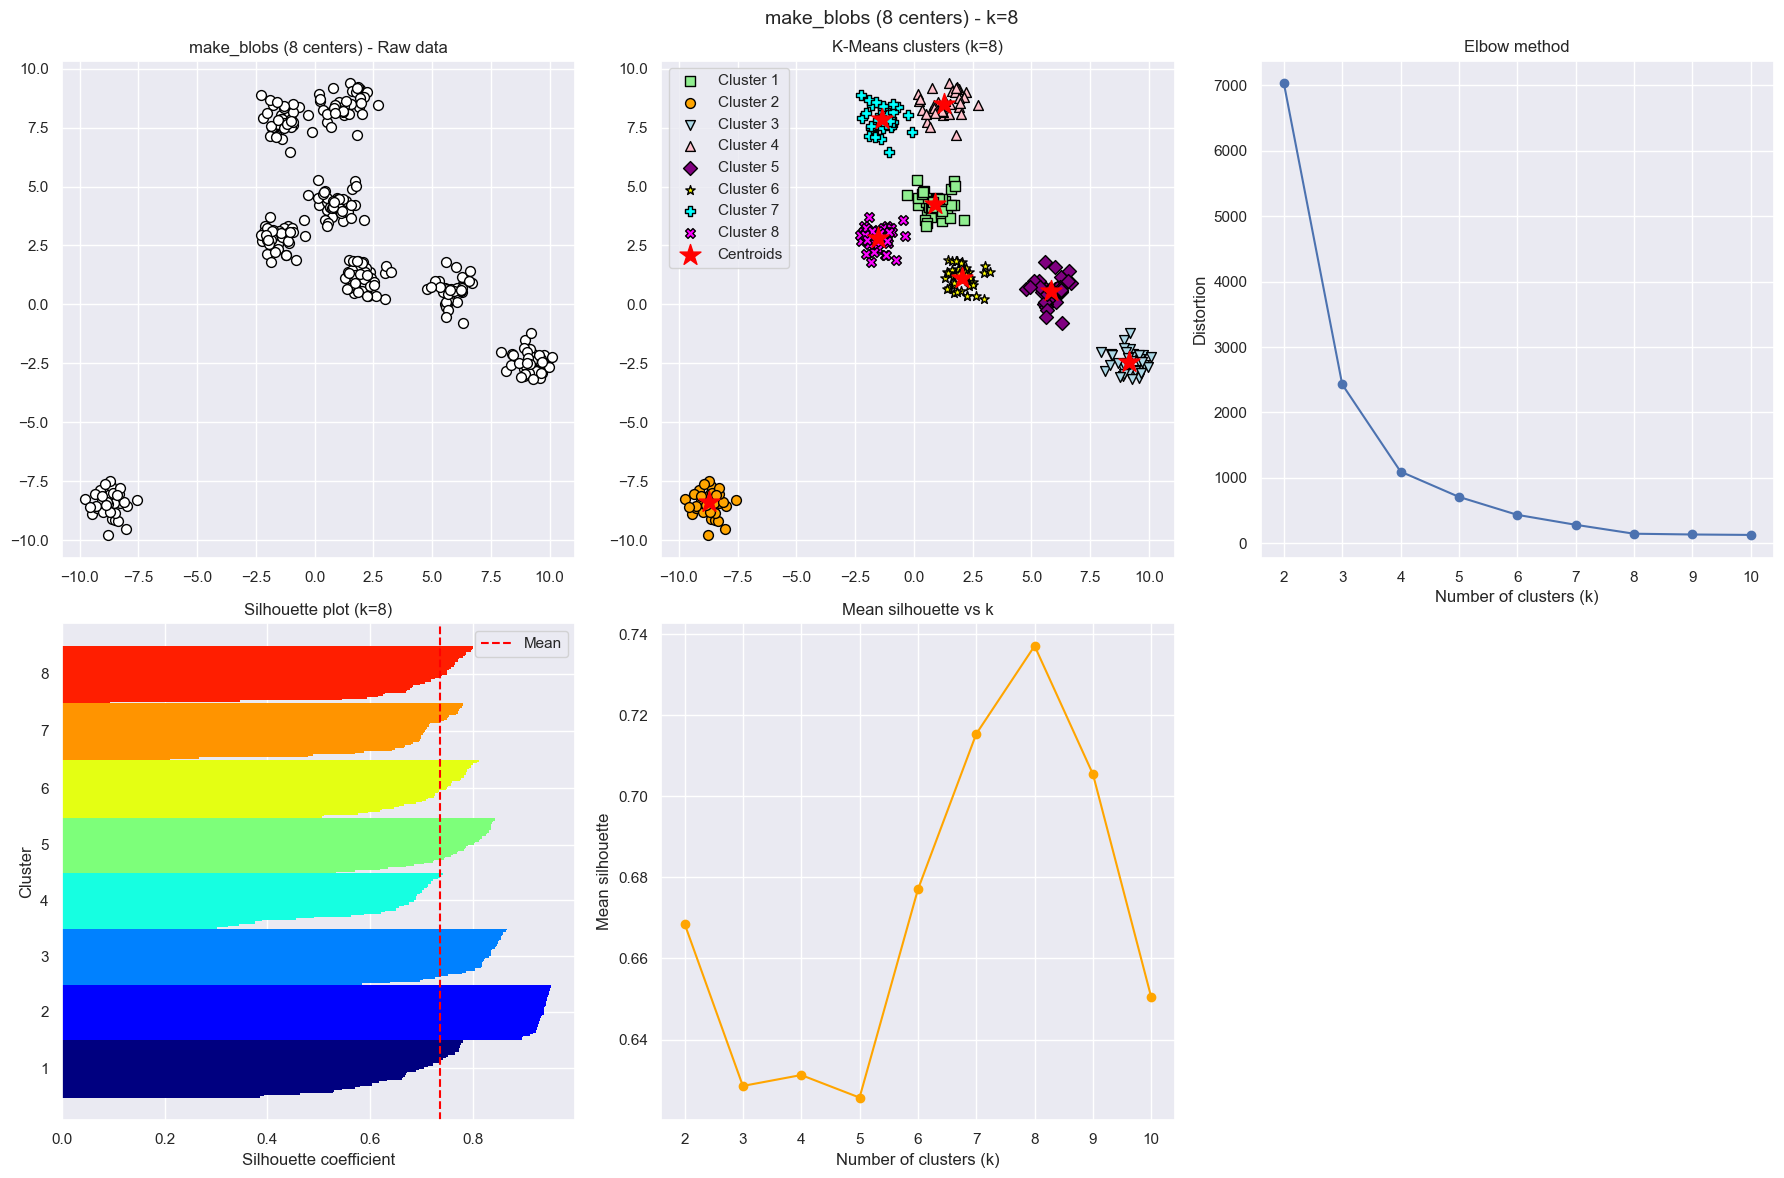


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

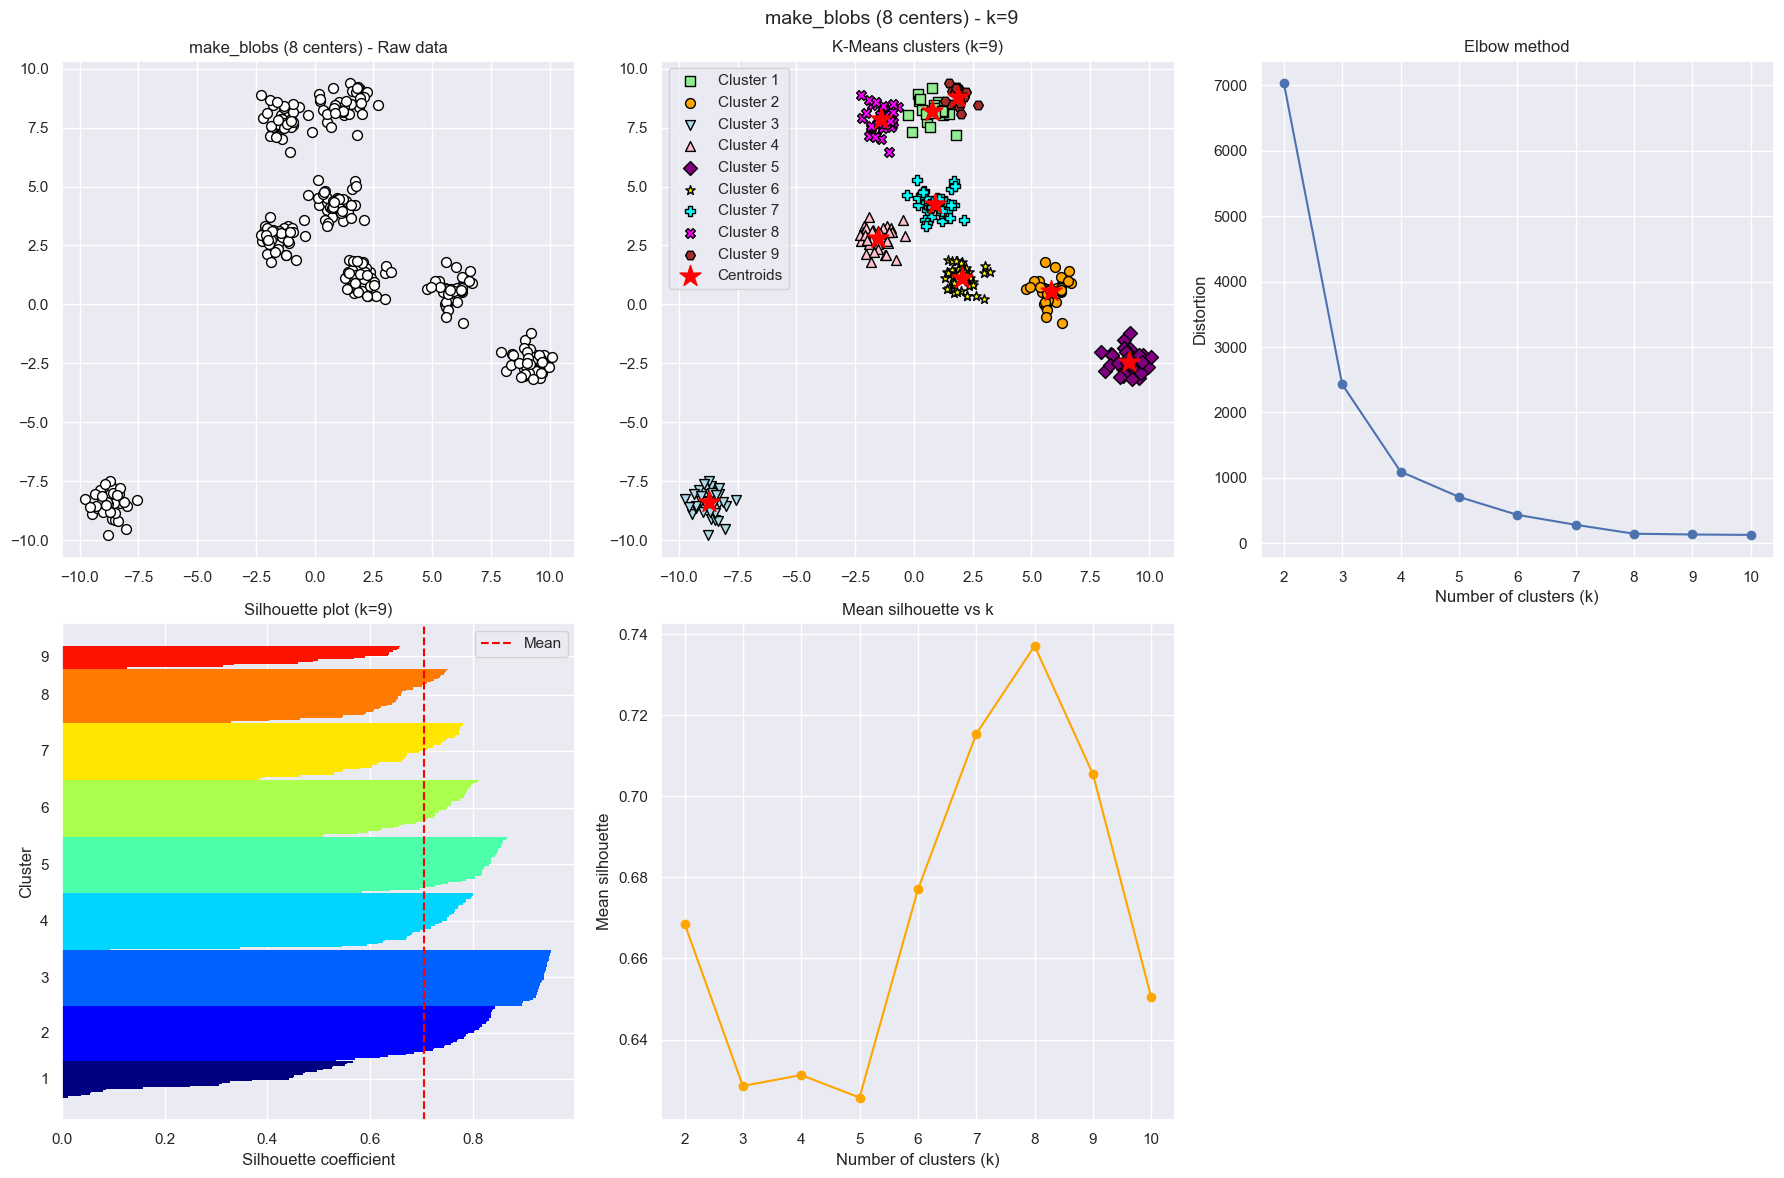


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

C:\Users\Manuel\AppData\Local\Temp\ipykernel_17828\2645685922.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[1].scatter(


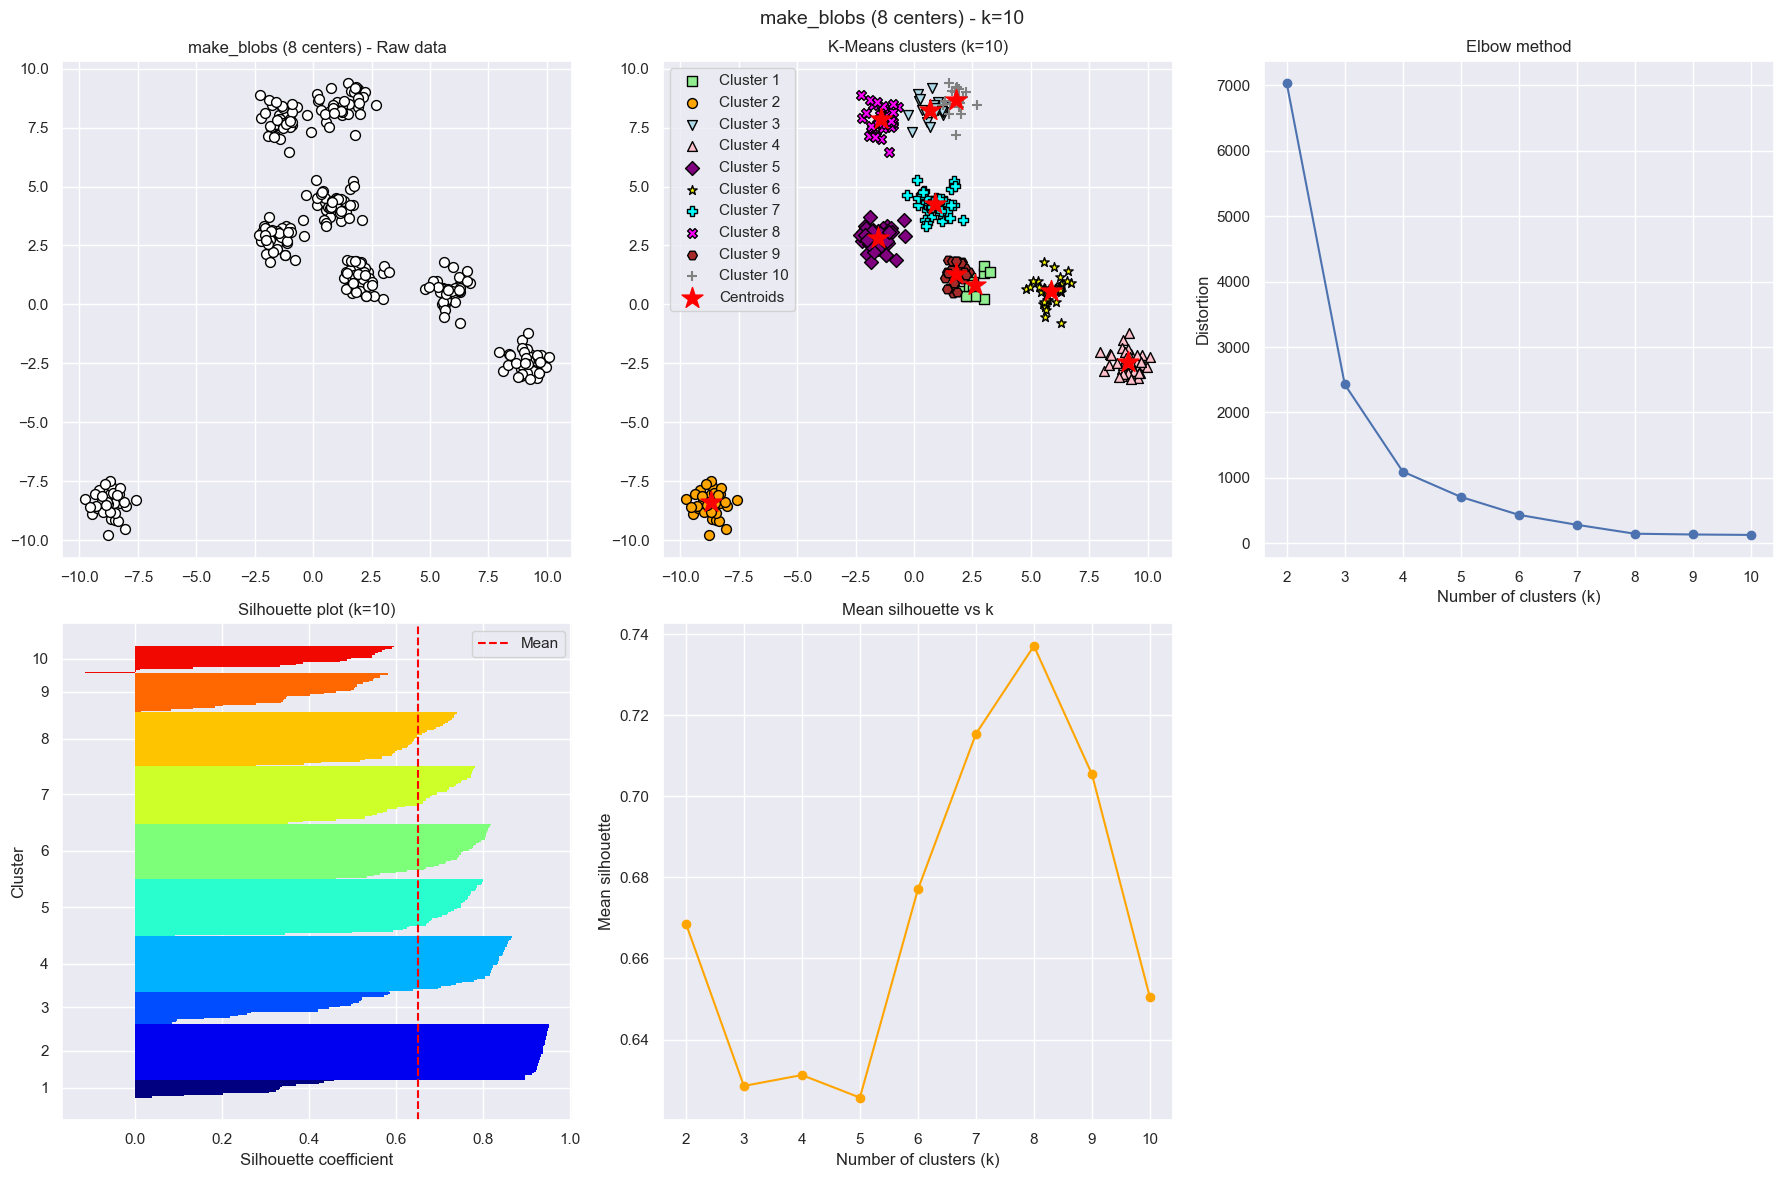


Results for make_blobs (8 centers):
 k  distortion  silhouette                                                                                                                                                centroids                dataset
 2     7033.77     0.66861                                                                                                                            (2.30, 3.25) | (-8.71, -8.40) make_blobs (8 centers)
 3     2428.42     0.62856                                                                                                            (0.24, 4.94) | (-8.71, -8.40) | (7.38, -0.91) make_blobs (8 centers)
 4     1095.04     0.63125                                                                                            (0.47, 2.74) | (-8.71, -8.40) | (7.50, -0.94) | (-0.05, 8.16) make_blobs (8 centers)
 5      708.26     0.62568                                                                             (0.24, 2.94) | (-8.71, -8.40) | (5.11, 0.63) | (

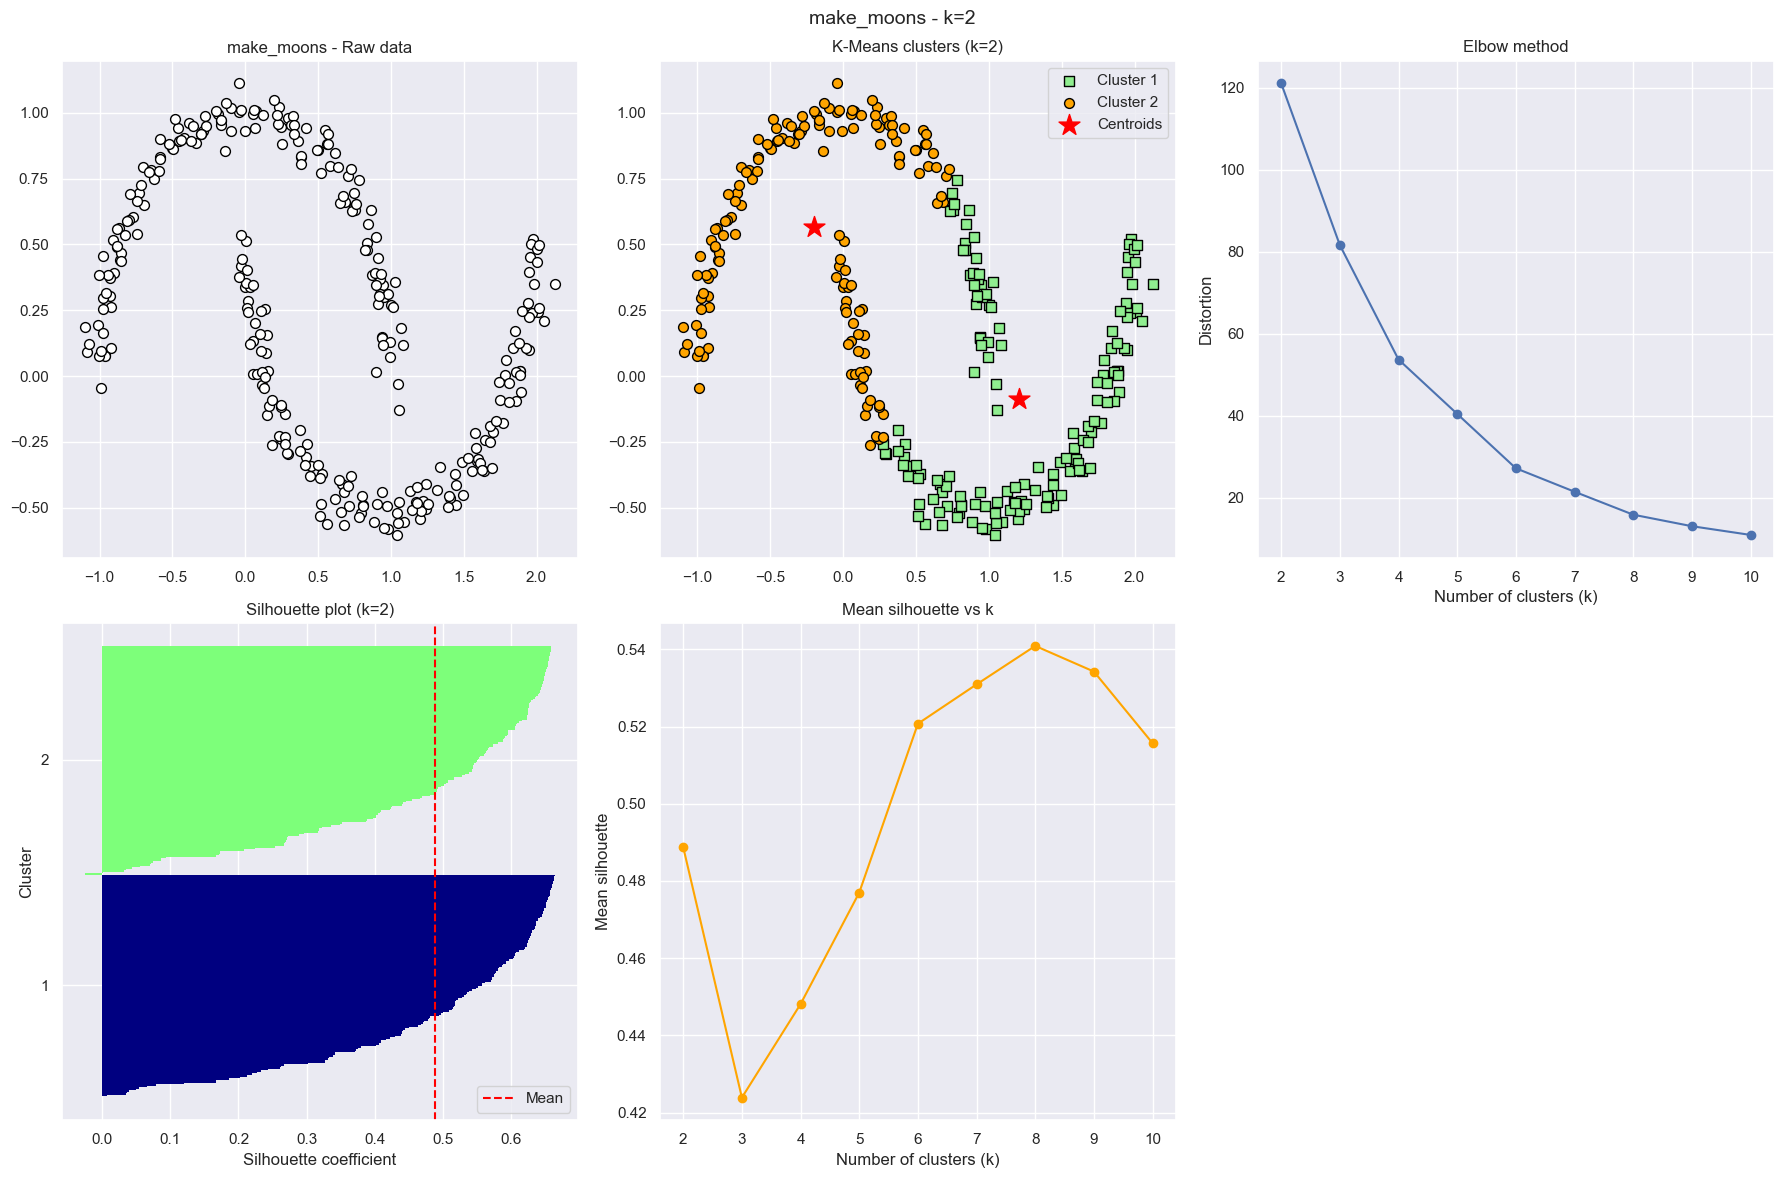


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57)
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27)
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05)
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34)
 6       27.19     0.52073                                                 

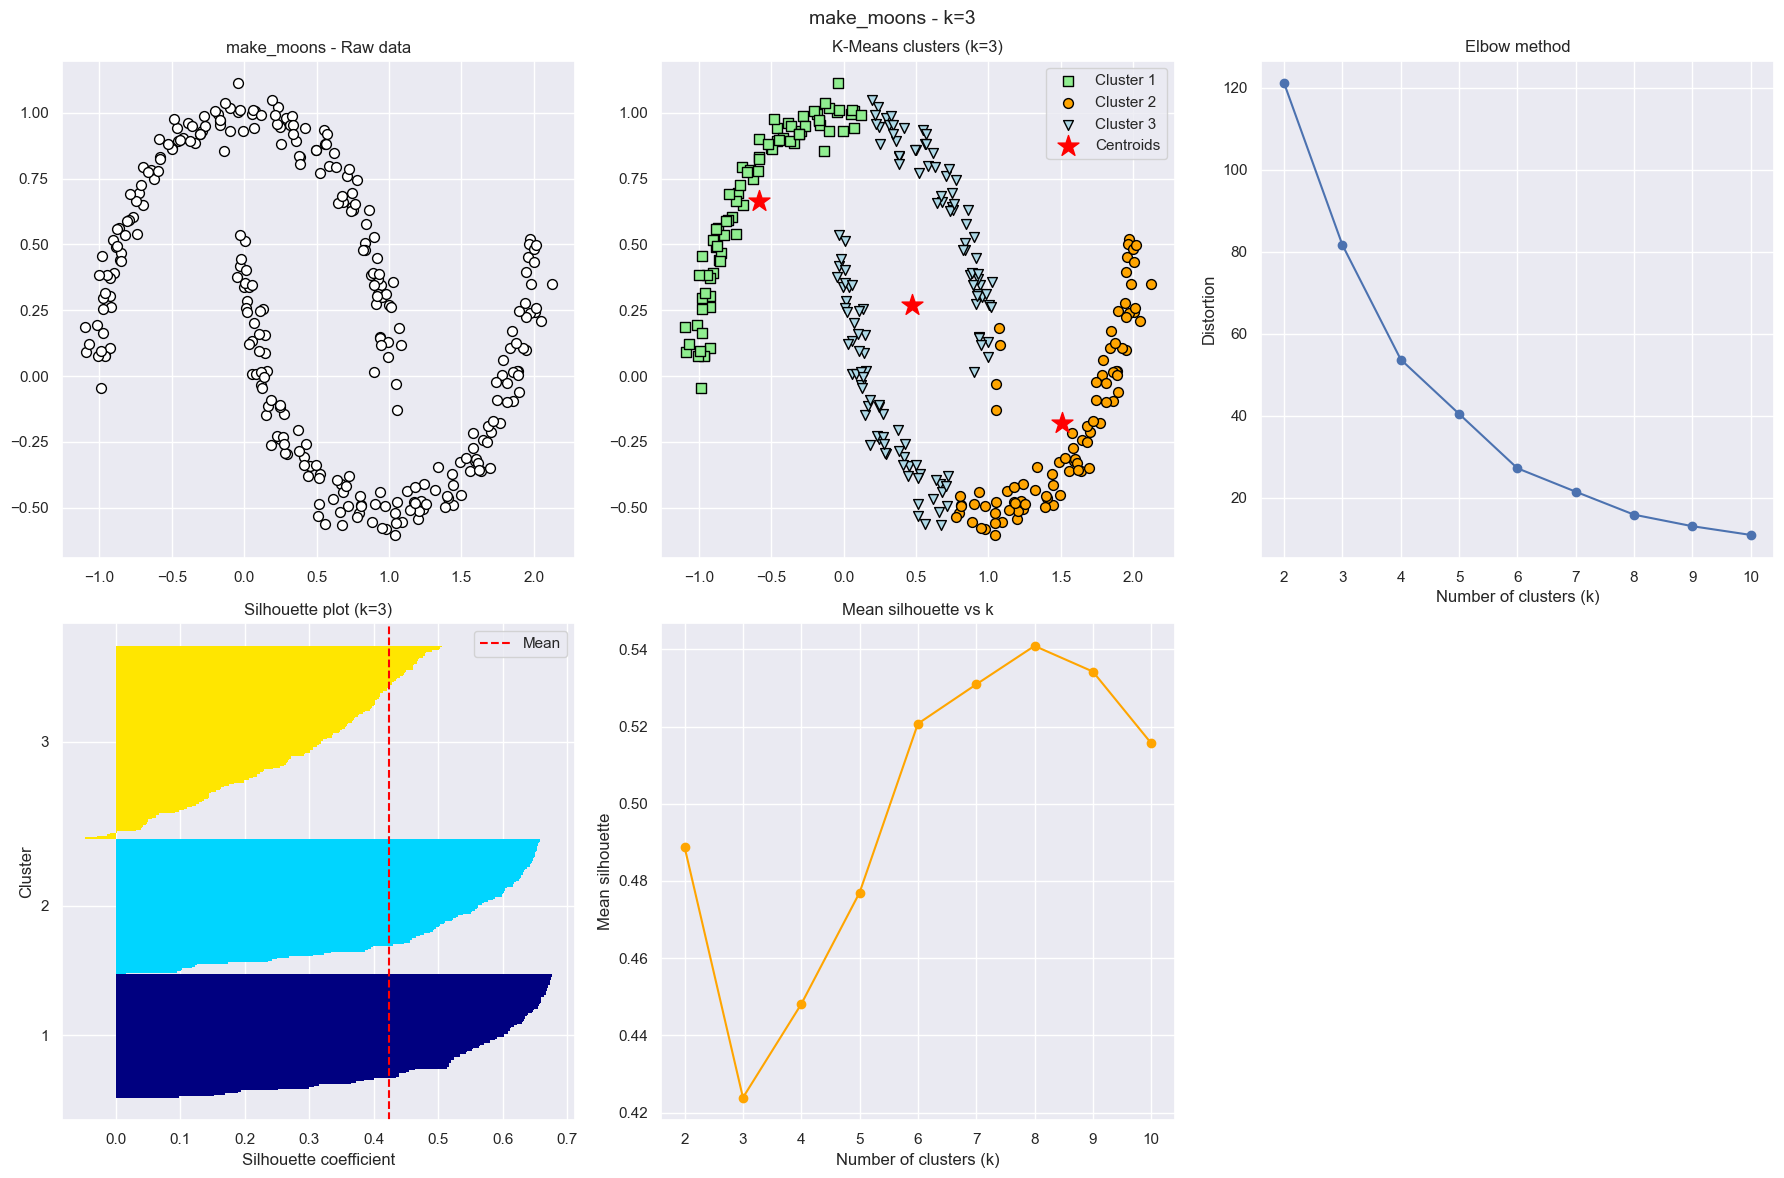


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

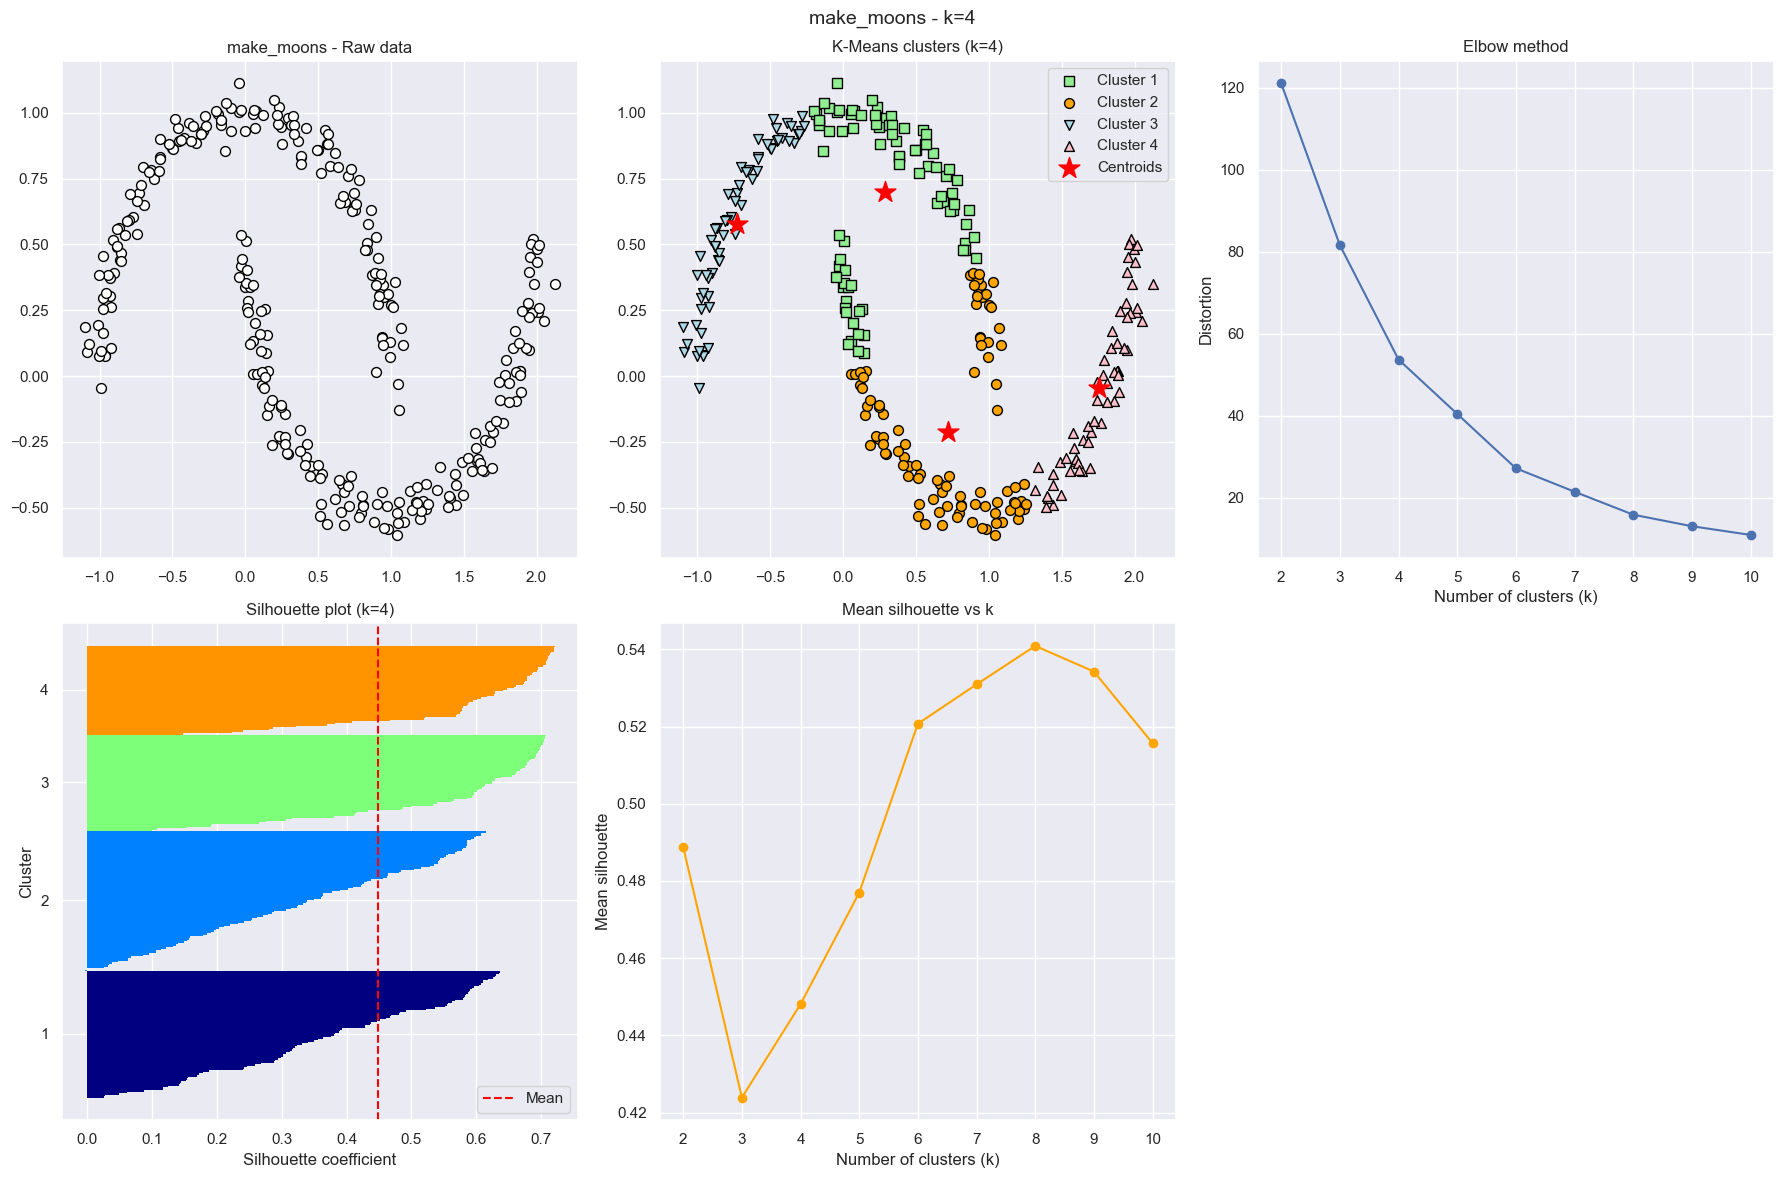


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

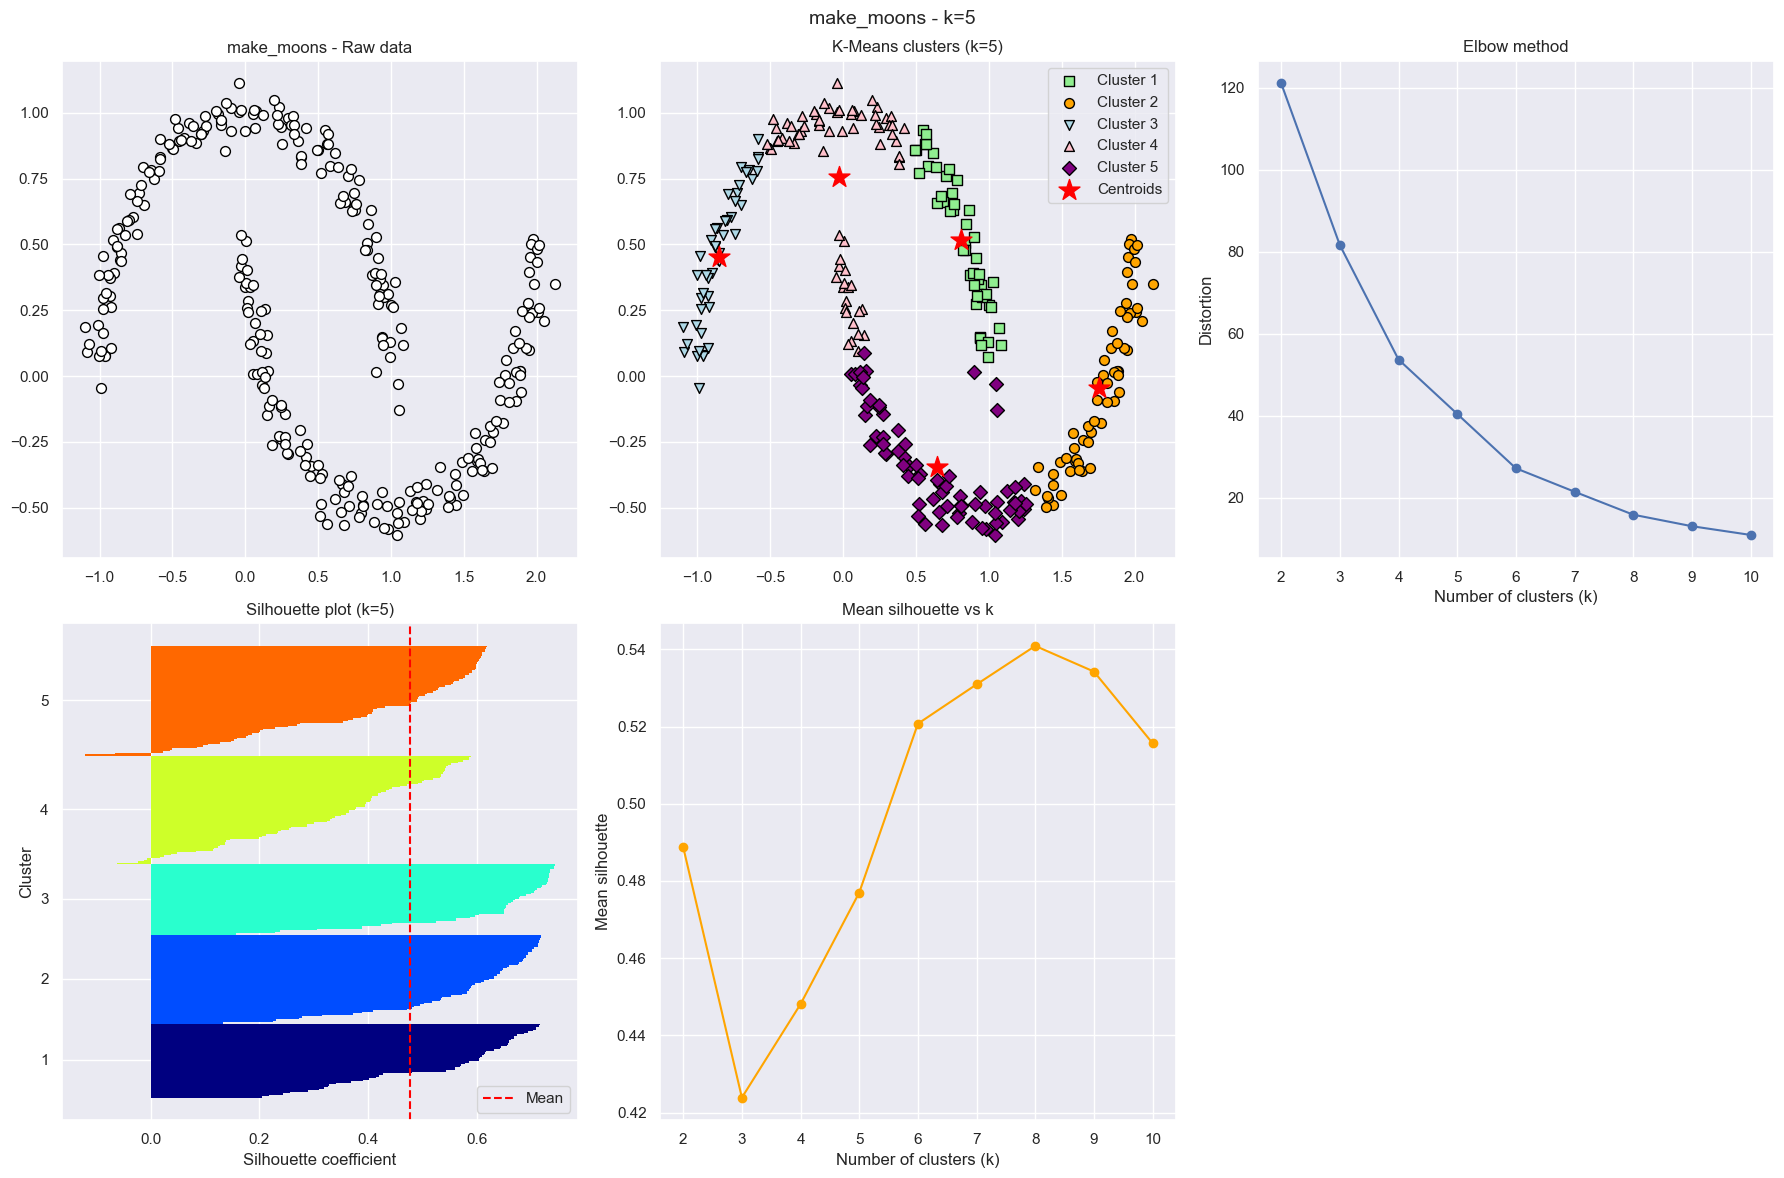


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

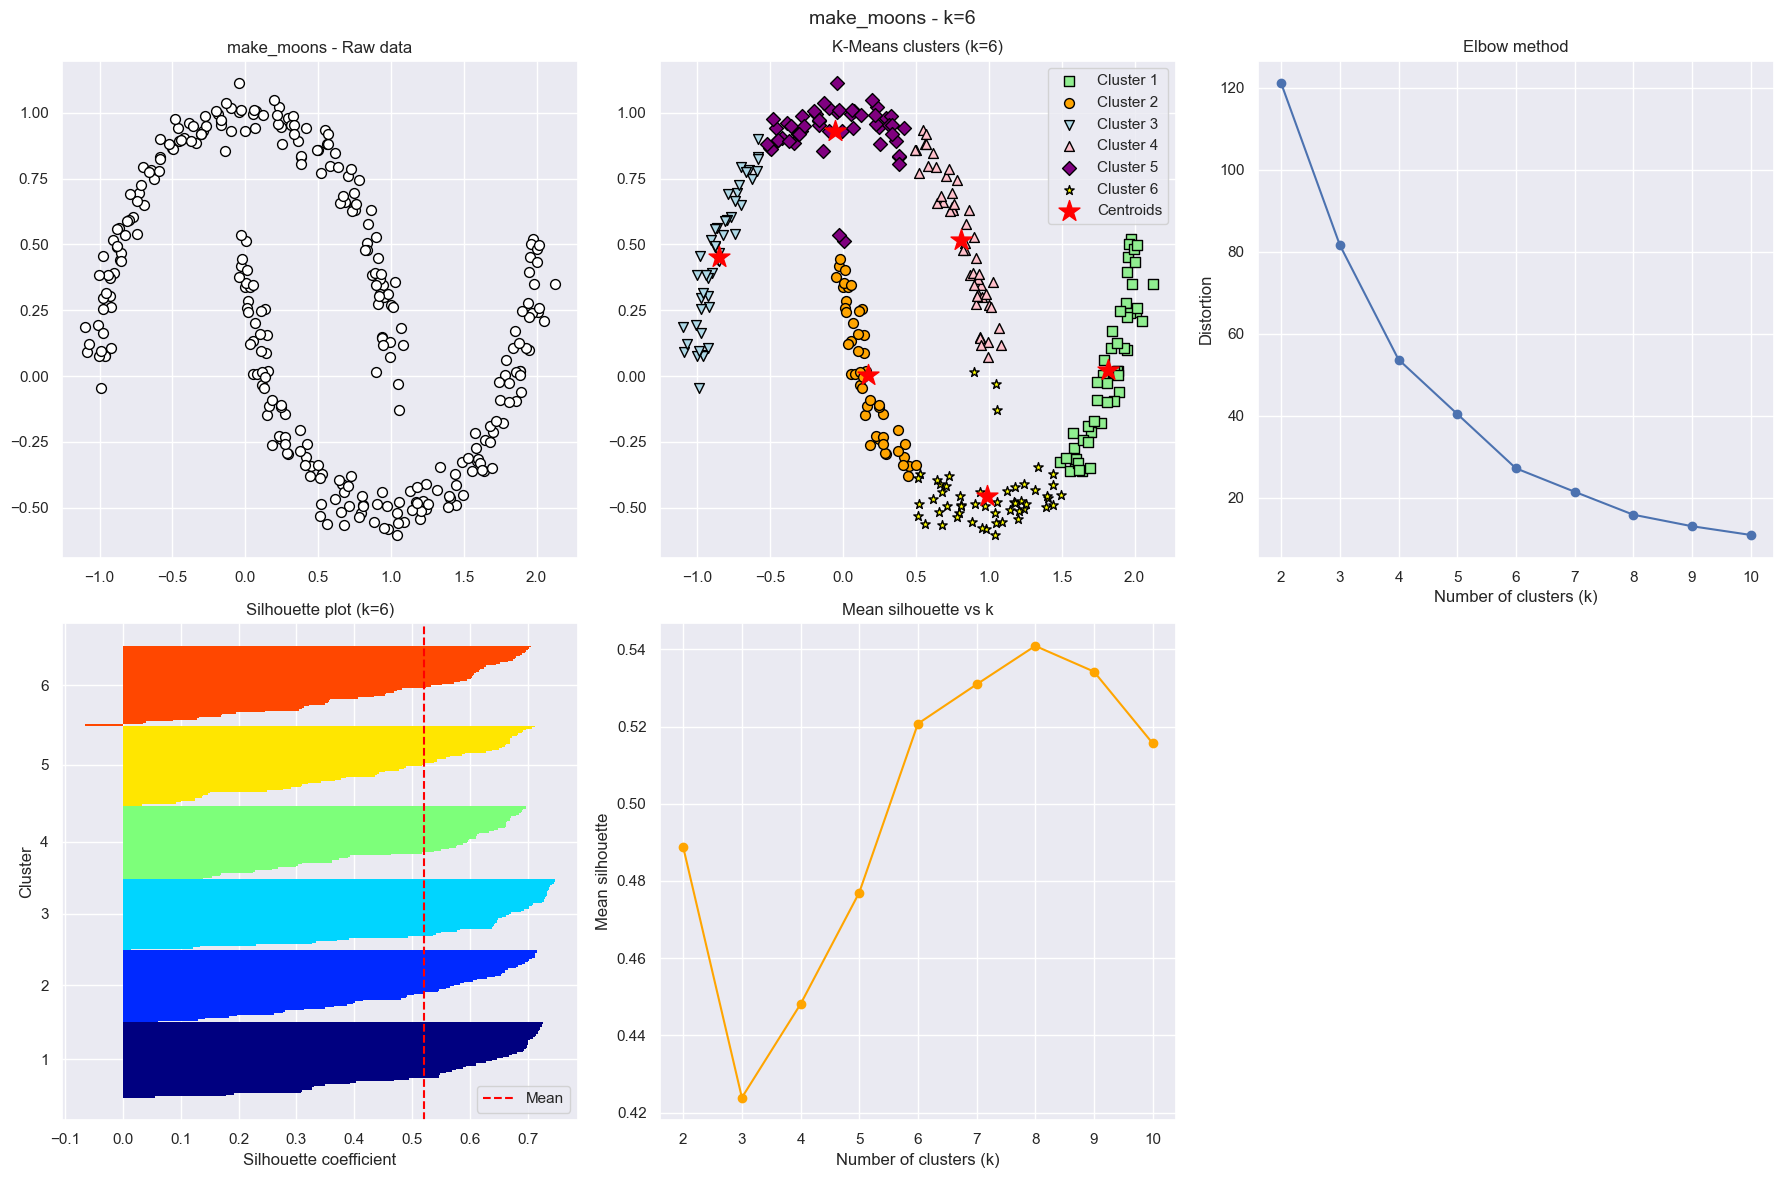


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

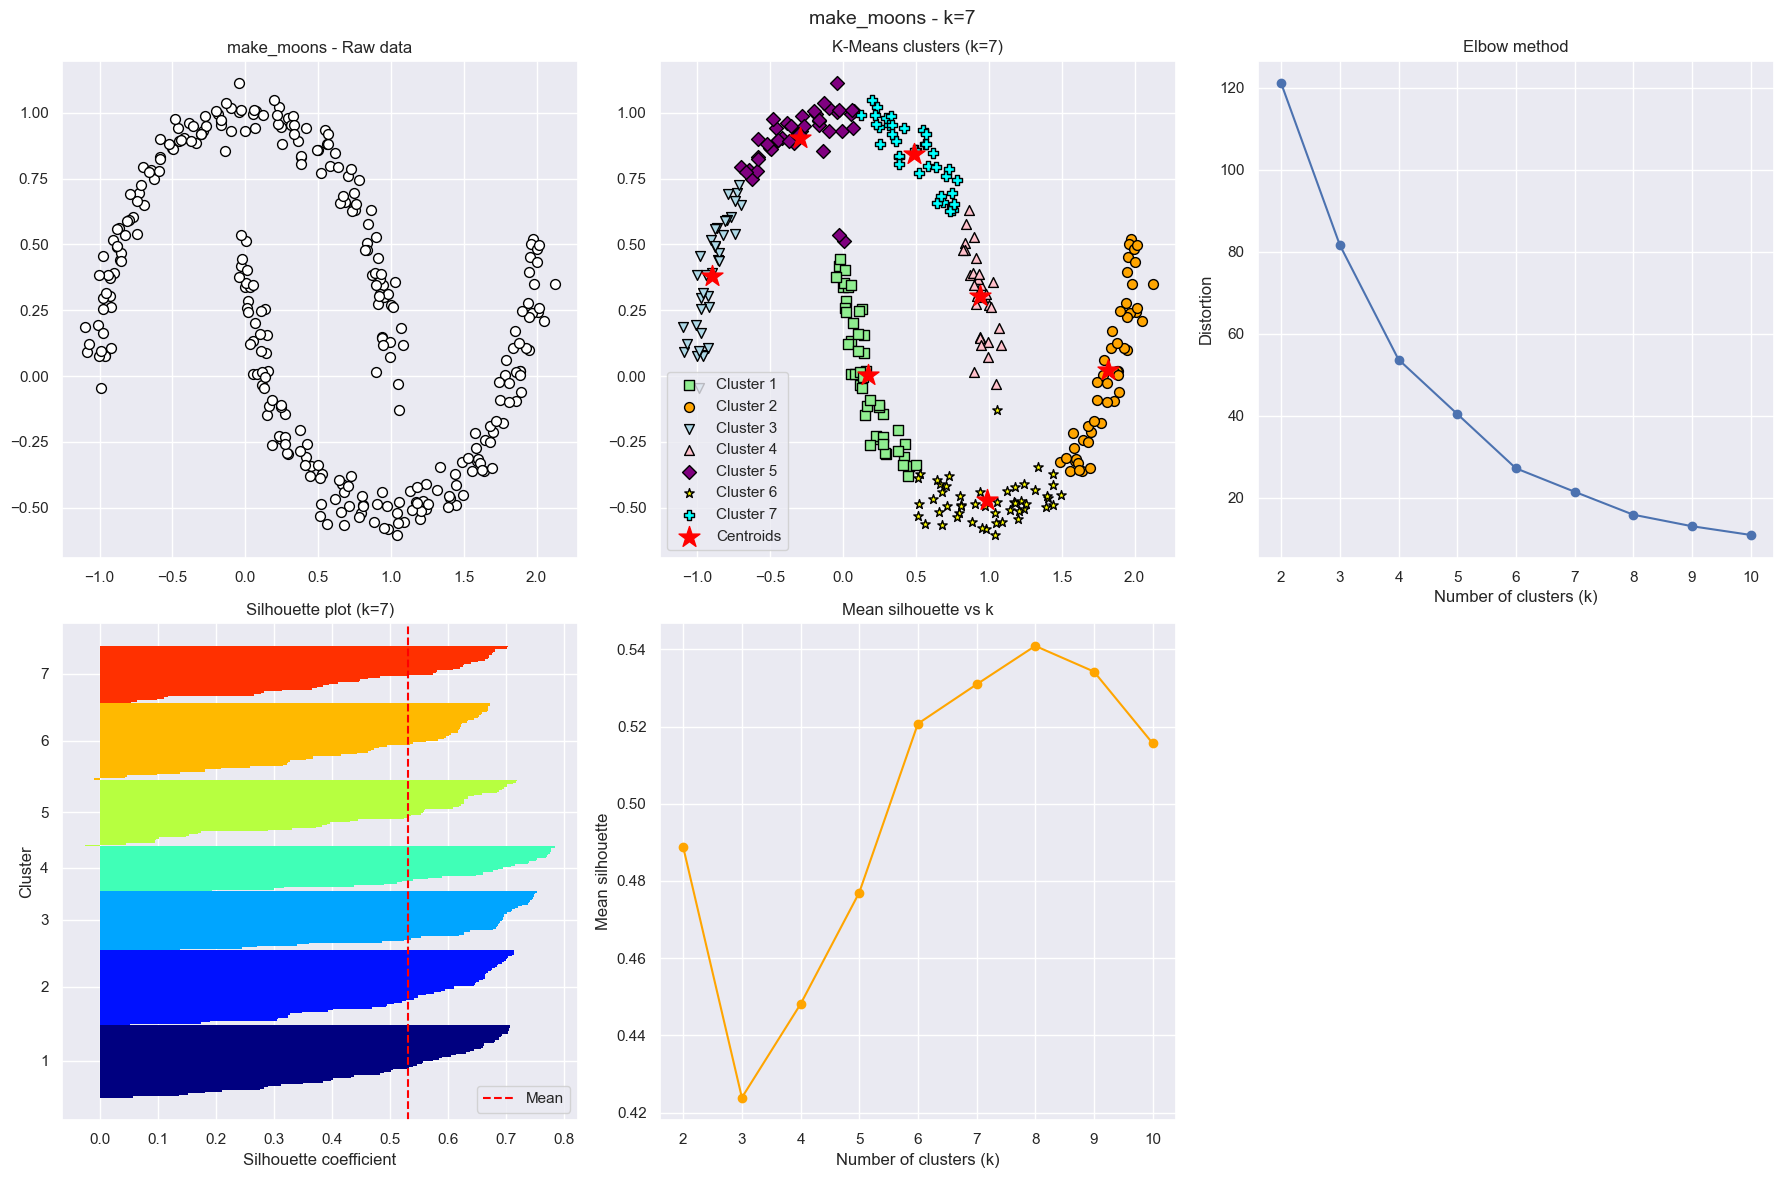


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

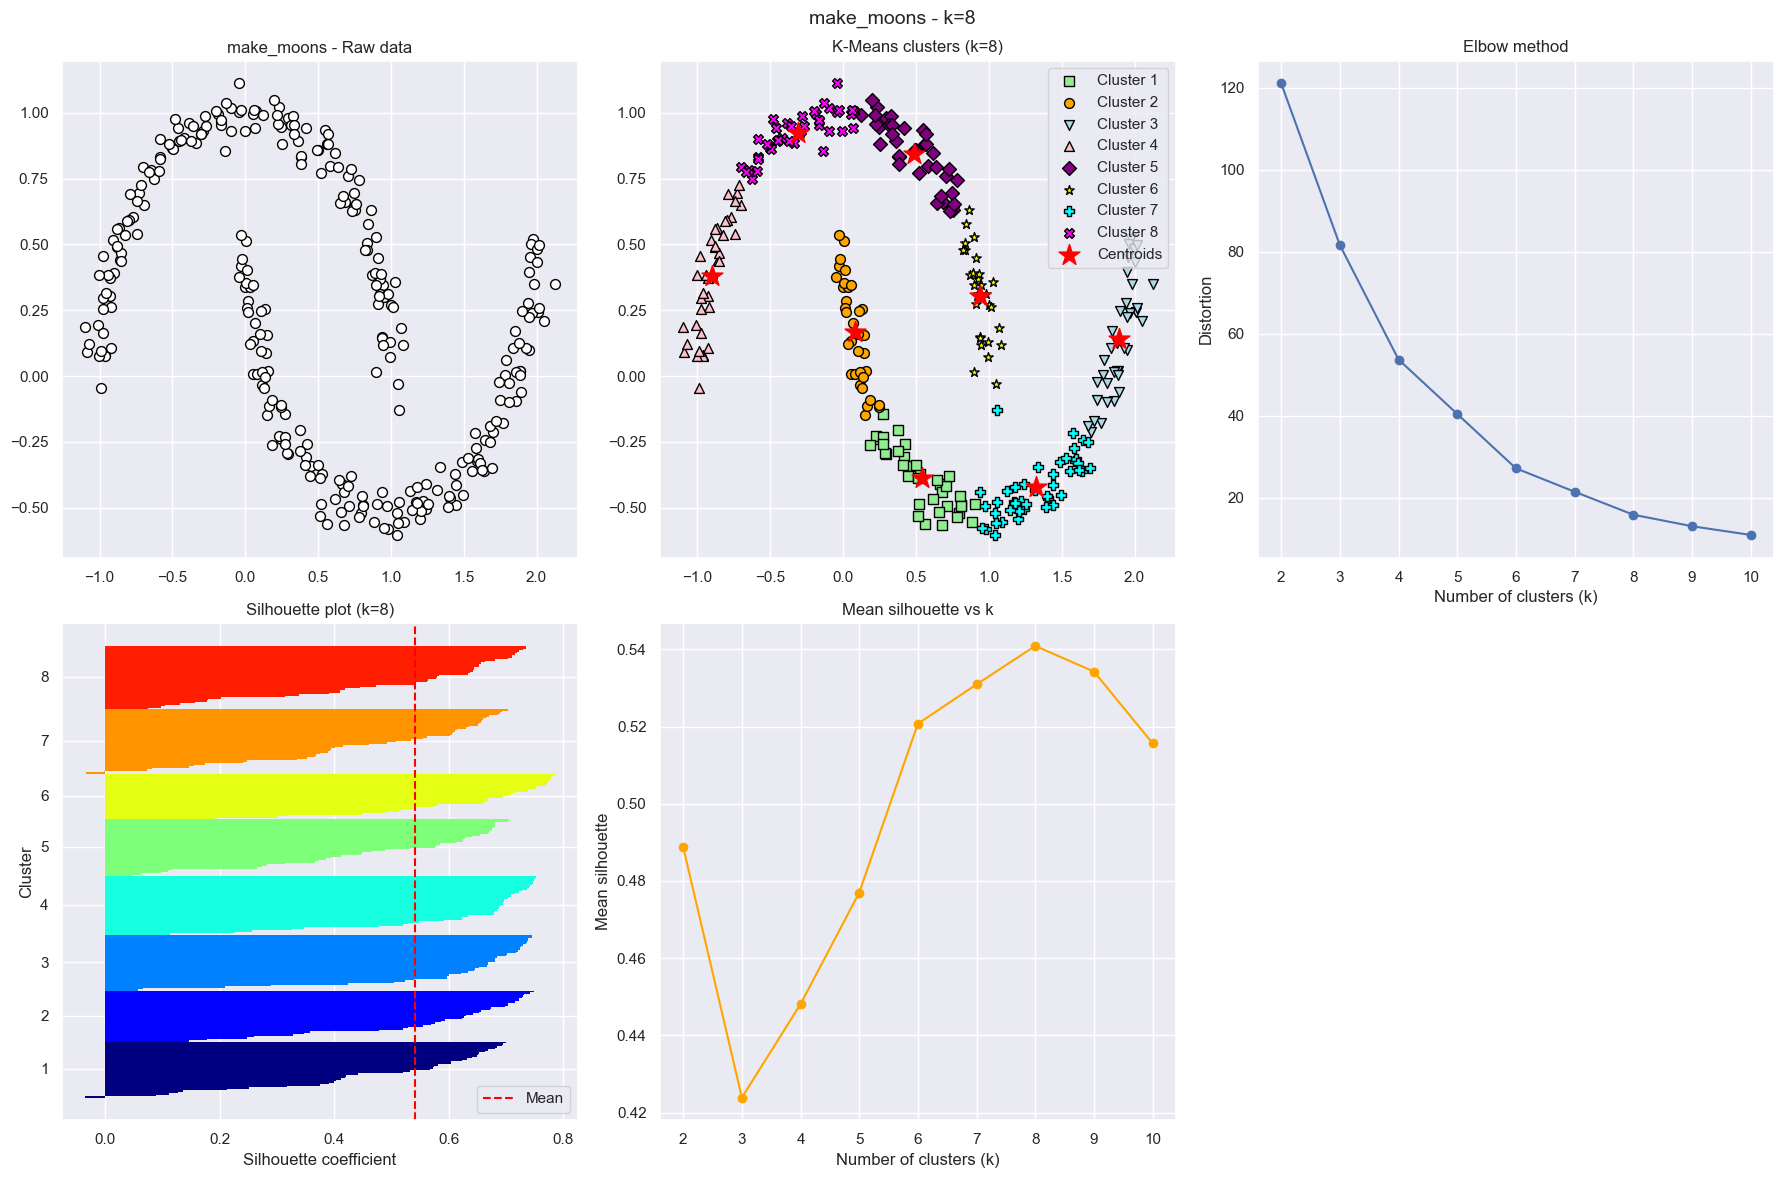


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

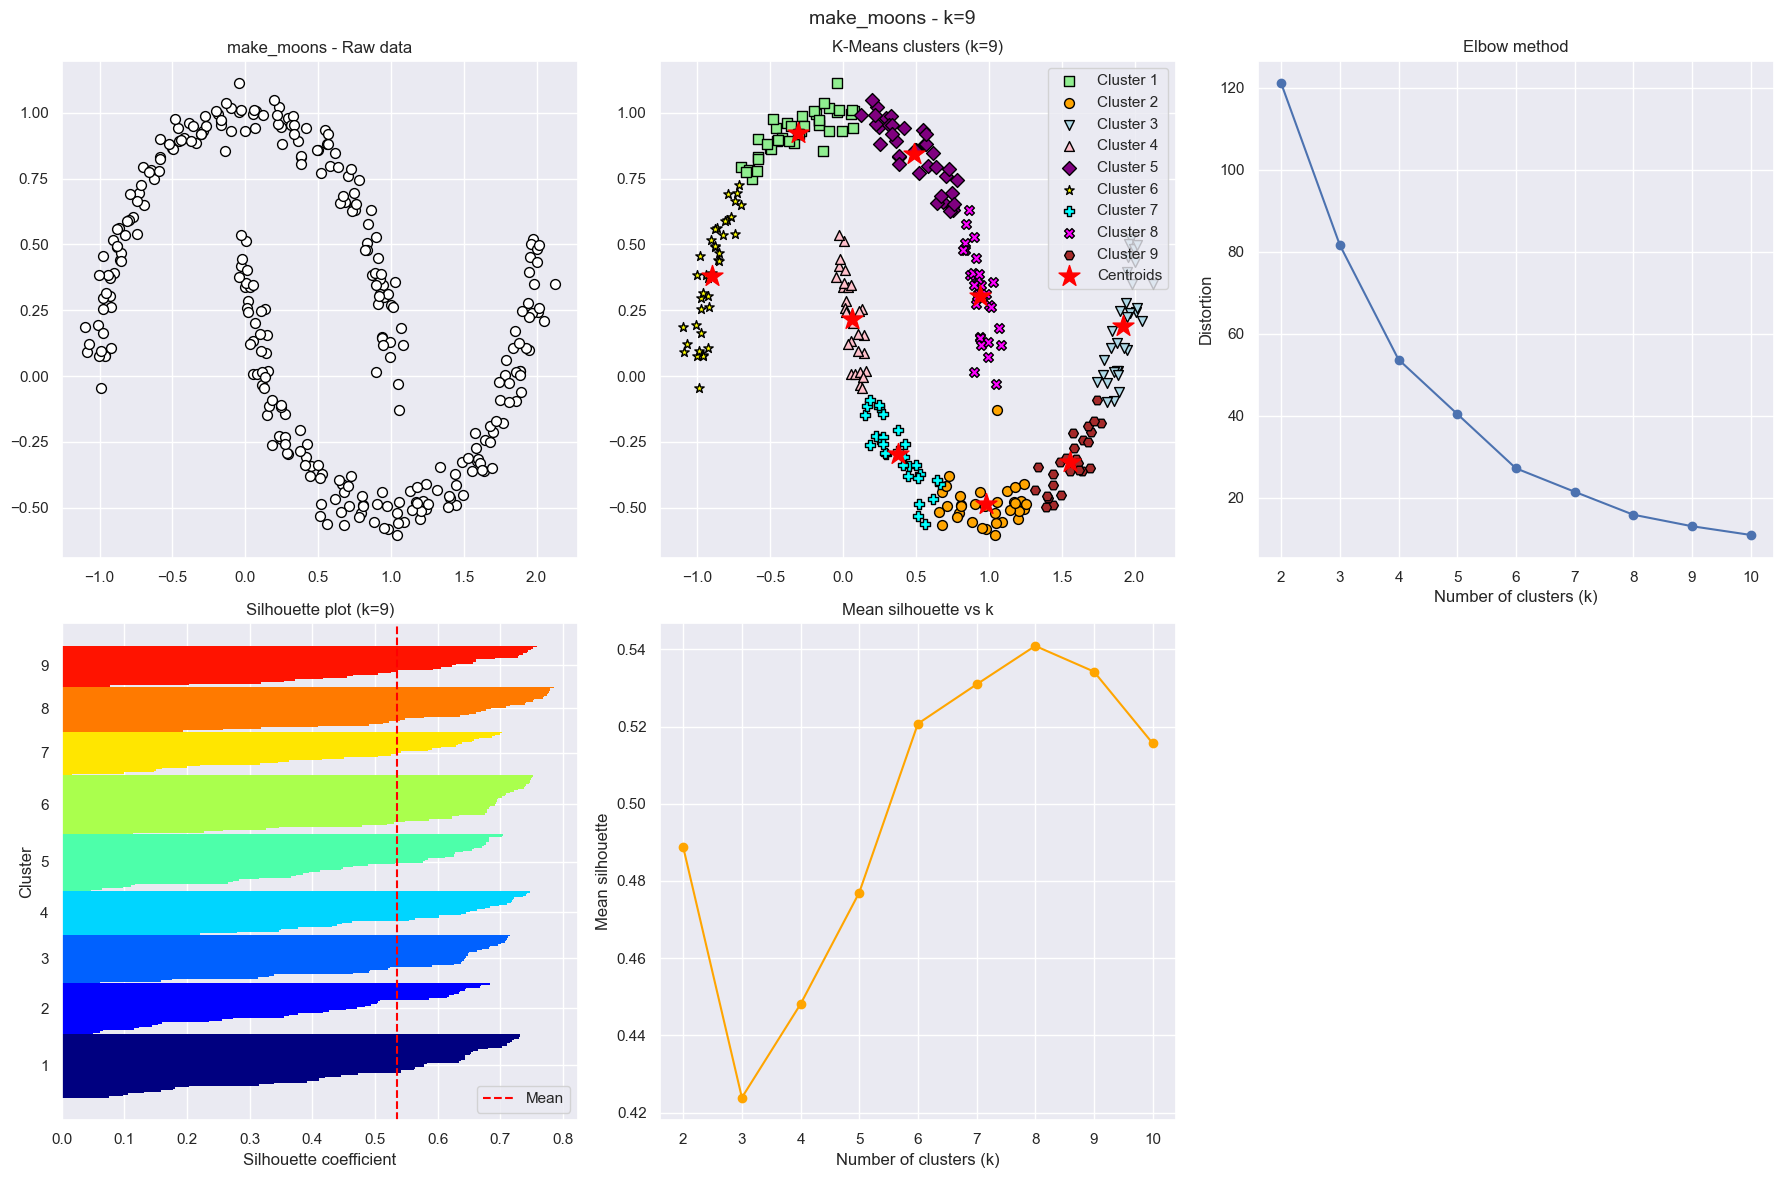


Results for make_moons:
 k  distortion  silhouette                                                                                                                                                centroids    dataset
 2      121.14     0.48874                                                                                                                            (1.20, -0.09) | (-0.20, 0.57) make_moons
 3       81.66     0.42388                                                                                                             (-0.58, 0.67) | (1.51, -0.18) | (0.47, 0.27) make_moons
 4       53.73     0.44810                                                                                             (0.29, 0.70) | (0.72, -0.21) | (-0.73, 0.58) | (1.76, -0.05) make_moons
 5       40.46     0.47698                                                                             (0.81, 0.52) | (1.76, -0.05) | (-0.85, 0.45) | (-0.03, 0.76) | (0.65, -0.34) make_moons
 6       27.19     0

C:\Users\Manuel\AppData\Local\Temp\ipykernel_17828\2645685922.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[1].scatter(


In [ ]:
if __name__ == '__main__':
    compare_all()